# 📊 UAS Data Science — Week 1 Progress
## Business Understanding & Exploratory Data Analysis (EDA)

**Dataset:** Sales & Marketing Customer Dataset  
**Jumlah Data:** 15.000 baris, 30 kolom  
**Tujuan Project:** Menganalisis perilaku pelanggan dan membangun model prediksi customer churn

---

## 1. Business Understanding

### 1.1 Latar Belakang

Dalam industri e-commerce dan SaaS, **customer churn** (pelanggan yang berhenti berlangganan atau tidak melakukan pembelian kembali) merupakan salah satu masalah bisnis yang paling kritis. Kehilangan pelanggan yang sudah ada jauh lebih mahal dibandingkan mendapatkan pelanggan baru. Menurut penelitian, biaya akuisisi pelanggan baru bisa 5–7 kali lebih tinggi daripada mempertahankan pelanggan yang sudah ada.

Dataset ini mencakup data pelanggan dari berbagai negara (India, Germany, USA, UK, Bangladesh) dengan informasi demografis, perilaku belanja, engagement marketing, dan interaksi layanan pelanggan.

### 1.2 Problem Statement

> **Bagaimana cara memprediksi pelanggan mana yang berpotensi churn berdasarkan data perilaku, engagement, dan transaksi mereka?**

### 1.3 Tujuan Analisis

1. Memahami profil dan karakteristik pelanggan secara keseluruhan
2. Mengidentifikasi pola perilaku pelanggan yang churn vs tidak churn
3. Menemukan fitur-fitur paling berpengaruh terhadap keputusan churn
4. Membangun fondasi data yang bersih untuk pemodelan prediktif di progress berikutnya

### 1.4 Pertanyaan Bisnis (Business Questions)

- Apakah pelanggan premium cenderung lebih setia dibandingkan pelanggan biasa?
- Channel akuisisi mana yang menghasilkan pelanggan paling loyal?
- Apakah kepuasan pelanggan (satisfaction score) berkorelasi kuat dengan churn?
- Bagaimana pola pengeluaran antara pelanggan yang churn dan yang tidak?

### 1.5 Target Variable

| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `churn` | Binary (0/1) | **0** = Pelanggan masih aktif, **1** = Pelanggan churn |

---

## 2. Import Library & Load Dataset

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')

import warnings
warnings.filterwarnings('ignore')

print(" Library berhasil diimport")

 Library berhasil diimport


In [2]:
# Load dataset
df = pd.read_csv('Sales - Marketing customer dataset.csv')

print(f" Dataset berhasil dimuat")
print(f" Jumlah baris   : {df.shape[0]:,}")
print(f" Jumlah kolom   : {df.shape[1]}")

 Dataset berhasil dimuat
 Jumlah baris   : 15,000
 Jumlah kolom   : 30


## 3. Pemahaman Data (Data Understanding)

### 3.1 Gambaran Umum Dataset

In [3]:
# Tampilkan 5 baris pertama
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.00,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,7,13.90,5.42,0.67,0.26,559.52,65.25,0,NEW20,0,0,3,UPI,3.00,10,27.56,915.31,14,0
1,10002,NaN,35.00,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,19,5.11,5.35,0.70,0.37,356.49,48.47,1,NEW20,5,0,3,BKash,3.00,7,15.15,2079.96,11,0
2,10003,Female,27.00,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,18,9.74,3.59,0.47,0.44,689.33,77.82,0,NaN,1,0,2,UPI,5.00,6,13.51,1379.15,9,0
3,10004,Female,36.00,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,16,9.64,2.95,0.58,0.37,445.43,71.71,0,NaN,0,0,2,PayPal,4.00,6,25.65,774.65,7,0
4,10005,Male,29.00,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,12,7.79,2.41,0.05,0.16,686.29,44.99,1,NaN,2,1,4,BKash,3.00,1,12.39,87.68,11,0


In [4]:
# Informasi tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [5]:
# Statistik deskriptif kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,15000.00,17500.50,4330.27,10001.00,13750.75,17500.50,21250.25,25000.00
age,13800.00,35.20,10.33,-4.00,28.00,35.00,42.00,95.00
is_premium_user,15000.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
total_visits,15000.00,15.00,3.89,3.00,12.00,15.00,18.00,31.00
avg_session_time,15000.00,8.02,2.99,0.01,5.97,7.99,10.06,19.12
pages_per_session,15000.00,4.00,1.48,0.01,2.99,4.00,5.01,10.84
email_open_rate,15000.00,0.50,0.29,0.00,0.24,0.50,0.75,1.00
email_click_rate,15000.00,0.25,0.14,0.00,0.13,0.25,0.38,0.50
total_spent,13950.00,524.36,467.05,0.27,300.43,498.84,702.40,15910.43
avg_order_value,15000.00,60.08,24.75,0.07,43.03,60.11,76.89,154.55


### 3.2 Penjelasan Fitur (Data Dictionary)

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `customer_id` | int | ID unik pelanggan |
| `gender` | kategori | Jenis kelamin (Male / Female / Other) |
| `age` | numerik | Usia pelanggan |
| `country` | kategori | Negara asal pelanggan |
| `city` | kategori | Kota pelanggan |
| `signup_date` | datetime | Tanggal registrasi |
| `last_purchase_date` | datetime | Tanggal pembelian terakhir |
| `acquisition_channel` | kategori | Channel akuisisi (Email, Organic, dsb) |
| `device_type` | kategori | Perangkat yang digunakan |
| `subscription_type` | kategori | Tipe langganan (Annual / Monthly) |
| `is_premium_user` | binary | Status premium (1=ya, 0=tidak) |
| `total_visits` | numerik | Total kunjungan ke platform |
| `avg_session_time` | numerik | Rata-rata durasi sesi (menit) |
| `pages_per_session` | numerik | Rata-rata halaman per sesi |
| `email_open_rate` | numerik | Persentase email yang dibuka |
| `email_click_rate` | numerik | Persentase klik pada email |
| `total_spent` | numerik | Total pengeluaran pelanggan |
| `avg_order_value` | numerik | Rata-rata nilai order |
| `discount_used` | binary | Penggunaan diskon (1=ya, 0=tidak) |
| `coupon_code` | kategori | Kode kupon yang digunakan |
| `support_tickets` | numerik | Jumlah tiket support yang dibuka |
| `refund_requested` | binary | Permintaan refund (1=ya, 0=tidak) |
| `delivery_delay_days` | numerik | Jumlah hari keterlambatan pengiriman |
| `payment_method` | kategori | Metode pembayaran |
| `satisfaction_score` | numerik | Skor kepuasan (1–5) |
| `nps_score` | numerik | Net Promoter Score (0–10) |
| `marketing_spend_per_user` | numerik | Pengeluaran marketing per user |
| `lifetime_value` | numerik | Customer Lifetime Value (CLV) |
| `last_3_month_purchase_freq` | numerik | Frekuensi pembelian 3 bulan terakhir |
| `churn` | binary | Target: apakah pelanggan churn (1=ya) |

## 4. Analisis Missing Values & Kualitas Data

### 4.1 Identifikasi Missing Values

In [6]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0').sort_values('Persentase (%)', ascending=False)

print("Kolom dengan Missing Values:")
print(missing_df.to_string())

Kolom dengan Missing Values:
                    Jumlah Missing  Persentase (%)
coupon_code                   6133           40.89
age                           1200            8.00
total_spent                   1050            7.00
gender                         738            4.92
satisfaction_score             702            4.68


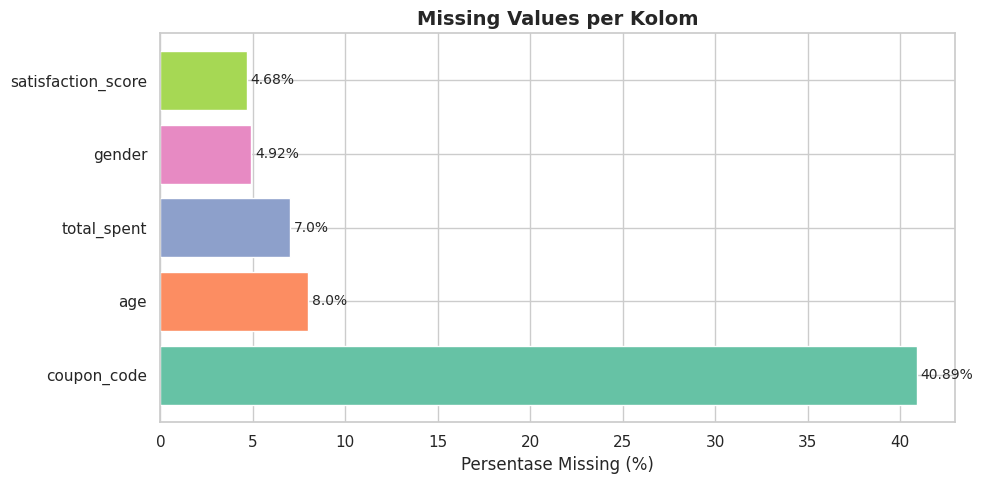


📌 Catatan:
- coupon_code memiliki 40.89% missing — kemungkinan pelanggan tidak menggunakan kupon (bisa diisi 'No Coupon')
- age, gender, total_spent, satisfaction_score perlu penanganan lebih lanjut di Week 2


In [7]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(missing_df.index, missing_df['Persentase (%)'],
               color=sns.color_palette('Set2', len(missing_df)))

for bar, val in zip(bars, missing_df['Persentase (%)']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)

ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Values per Kolom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Catatan:")
print("- coupon_code memiliki 40.89% missing — kemungkinan pelanggan tidak menggunakan kupon (bisa diisi 'No Coupon')")
print("- age, gender, total_spent, satisfaction_score perlu penanganan lebih lanjut di Week 2")

### 4.2 Deteksi Anomali / Data Tidak Wajar

In [8]:
# Cek anomali pada kolom age
print("=== Anomali Kolom 'age' ===")
print(f"Nilai minimum age : {df['age'].min()}")
print(f"Nilai maksimum age: {df['age'].max()}")
print(f"Age negatif (< 0) : {(df['age'] < 0).sum()} baris")
print(f"Age > 80          : {(df['age'] > 80).sum()} baris")
print()

# Cek total_spent = 0 atau sangat kecil
print("=== Anomali Kolom 'total_spent' ===")
print(f"total_spent = 0   : {(df['total_spent'] == 0).sum()} baris")
print(f"total_spent < 1   : {(df['total_spent'] < 1).sum()} baris")
print(f"total_spent max   : {df['total_spent'].max():.2f}")
print()

# Duplikasi data
print(f"=== Baris Duplikat ===")
print(f"Jumlah duplikat   : {df.duplicated().sum()}")

=== Anomali Kolom 'age' ===
Nilai minimum age : -4.0
Nilai maksimum age: 95.0
Age negatif (< 0) : 3 baris
Age > 80          : 30 baris

=== Anomali Kolom 'total_spent' ===
total_spent = 0   : 0 baris
total_spent < 1   : 6 baris
total_spent max   : 15910.43

=== Baris Duplikat ===
Jumlah duplikat   : 0


## 5. Analisis Target Variable: Churn

### 5.1 Distribusi Churn

Distribusi Churn:
  Tidak Churn (0): 12,702 pelanggan (84.7%)
  Churn (1)      : 2,298 pelanggan (15.3%)


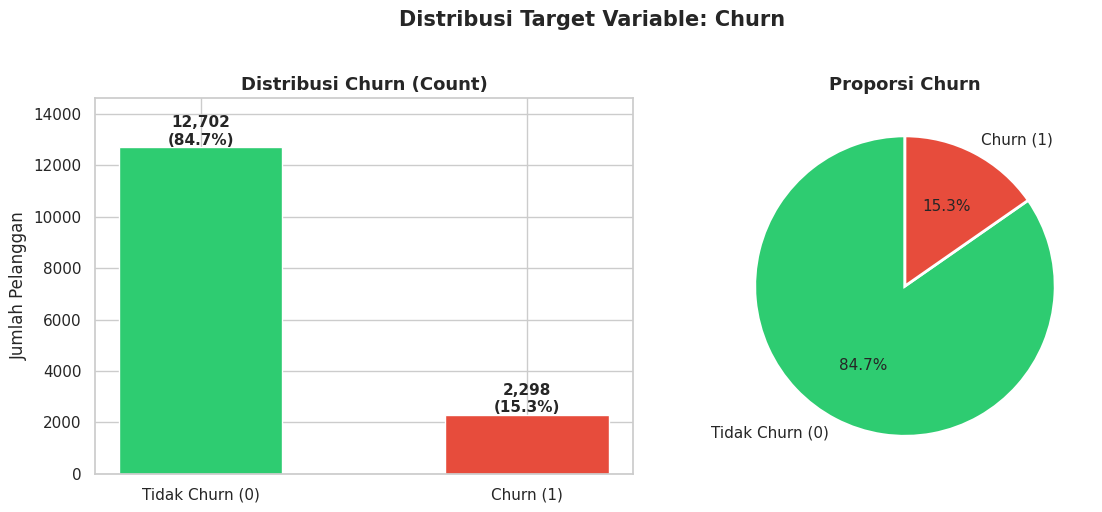


📌 Insight: Dataset mengalami class imbalance — pelanggan churn hanya 15.3%.
   Perlu penanganan khusus seperti SMOTE atau class_weight pada tahap pemodelan.


In [9]:
# Distribusi churn
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("Distribusi Churn:")
print(f"  Tidak Churn (0): {churn_counts[0]:,} pelanggan ({churn_pct[0]:.1f}%)")
print(f"  Churn (1)      : {churn_counts[1]:,} pelanggan ({churn_pct[1]:.1f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_counts, color=colors, edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, churn_counts, churn_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Churn (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, max(churn_counts) * 1.15)

# Pie chart
axes[1].pie(churn_counts, labels=['Tidak Churn (0)', 'Churn (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Churn', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Target Variable: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Insight: Dataset mengalami class imbalance — pelanggan churn hanya 15.3%.")
print("   Perlu penanganan khusus seperti SMOTE atau class_weight pada tahap pemodelan.")

## 6. EDA: Analisis Variabel Kategorik

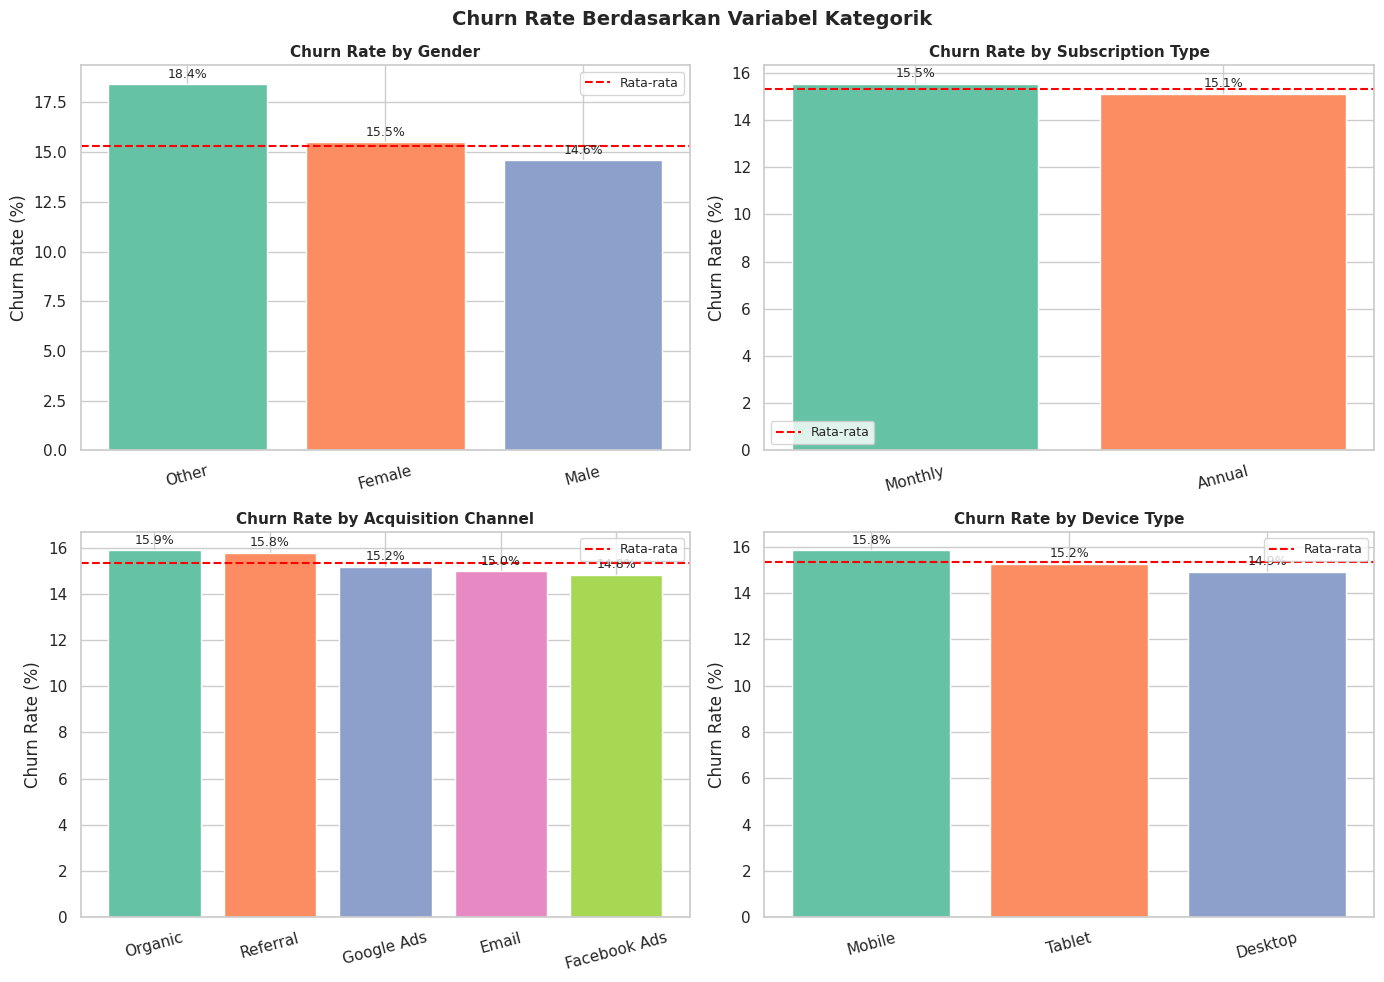

In [10]:
# Fungsi helper untuk plot churn rate per kategori
def plot_churn_by_category(col, title, ax):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('Set2', len(churn_rate)), edgecolor='white')
    ax.axhline(y=df['churn'].mean()*100, color='red', linestyle='--', linewidth=1.5, label='Rata-rata')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=15)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_churn_by_category('gender', 'Churn Rate by Gender', axes[0, 0])
plot_churn_by_category('subscription_type', 'Churn Rate by Subscription Type', axes[0, 1])
plot_churn_by_category('acquisition_channel', 'Churn Rate by Acquisition Channel', axes[1, 0])
plot_churn_by_category('device_type', 'Churn Rate by Device Type', axes[1, 1])

plt.suptitle('Churn Rate Berdasarkan Variabel Kategorik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

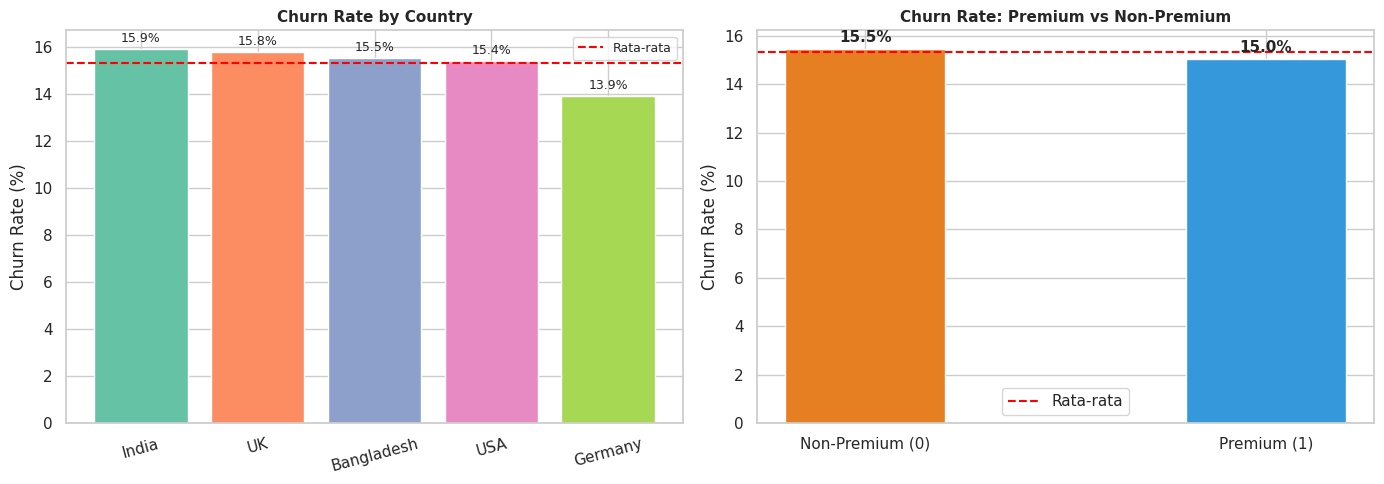

In [11]:
# Churn by Country & Premium Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_churn_by_category('country', 'Churn Rate by Country', axes[0])

# Premium user
premium_churn = df.groupby('is_premium_user')['churn'].mean() * 100
bars = axes[1].bar(['Non-Premium (0)', 'Premium (1)'], premium_churn.values,
                   color=['#e67e22', '#3498db'], edgecolor='white', width=0.4)
axes[1].axhline(y=df['churn'].mean()*100, color='red', linestyle='--', linewidth=1.5, label='Rata-rata')
for bar, val in zip(bars, premium_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Churn Rate: Premium vs Non-Premium', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. EDA: Analisis Variabel Numerik

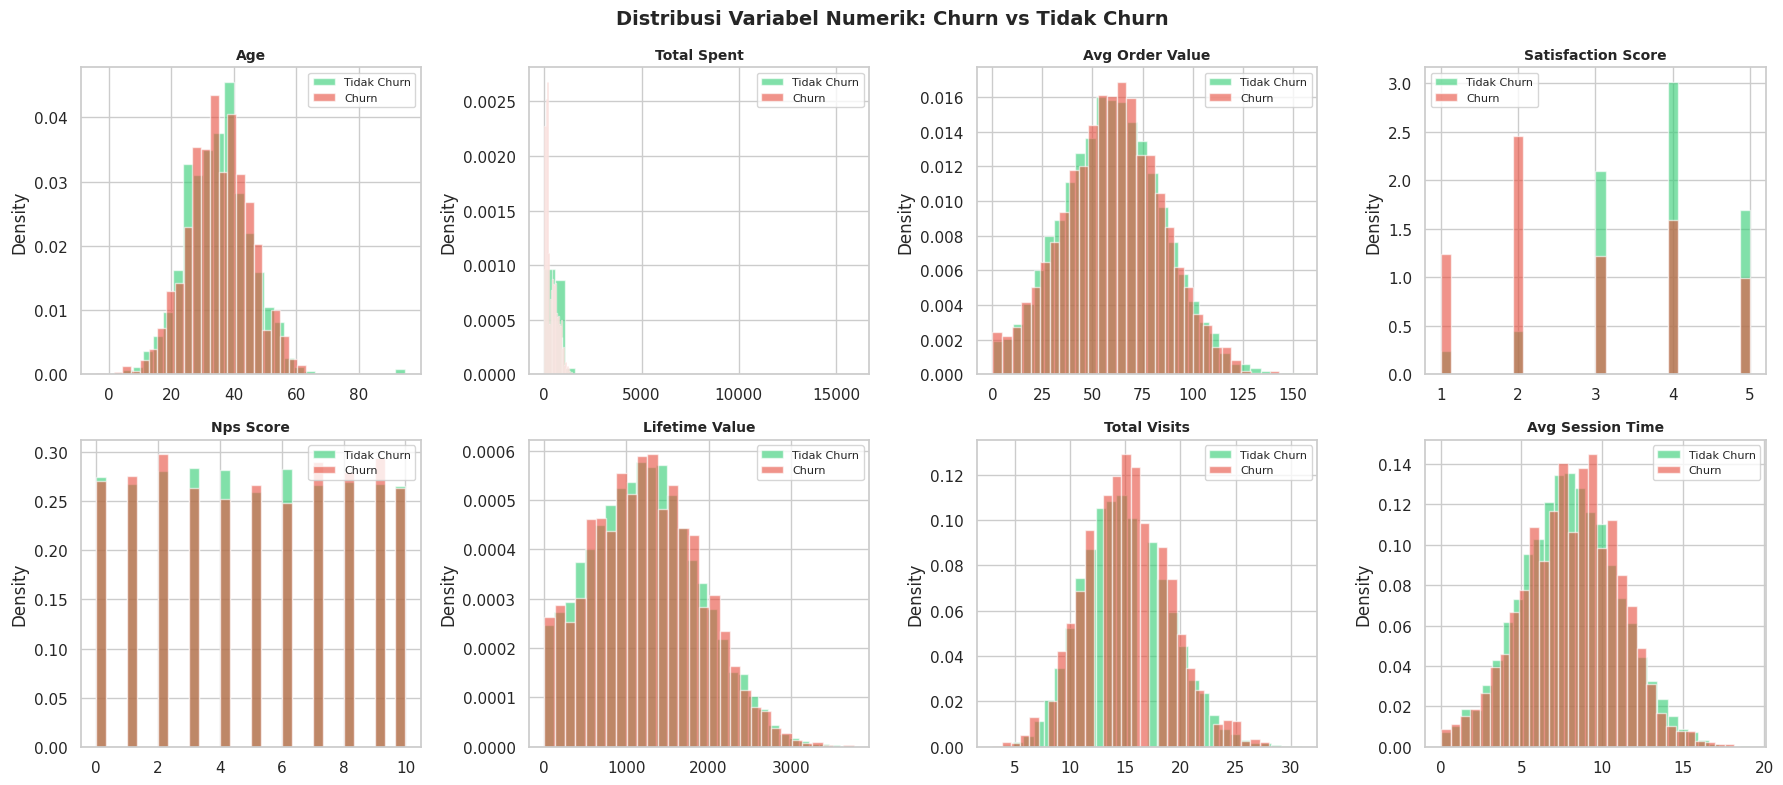

In [12]:
# Distribusi variabel numerik utama
num_cols = ['age', 'total_spent', 'avg_order_value', 'satisfaction_score',
            'nps_score', 'lifetime_value', 'total_visits', 'avg_session_time']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    churn_0 = df[df['churn'] == 0][col].dropna()
    churn_1 = df[df['churn'] == 1][col].dropna()
    axes[i].hist(churn_0, bins=30, alpha=0.6, color='#2ecc71', label='Tidak Churn', density=True)
    axes[i].hist(churn_1, bins=30, alpha=0.6, color='#e74c3c', label='Churn', density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Distribusi Variabel Numerik: Churn vs Tidak Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

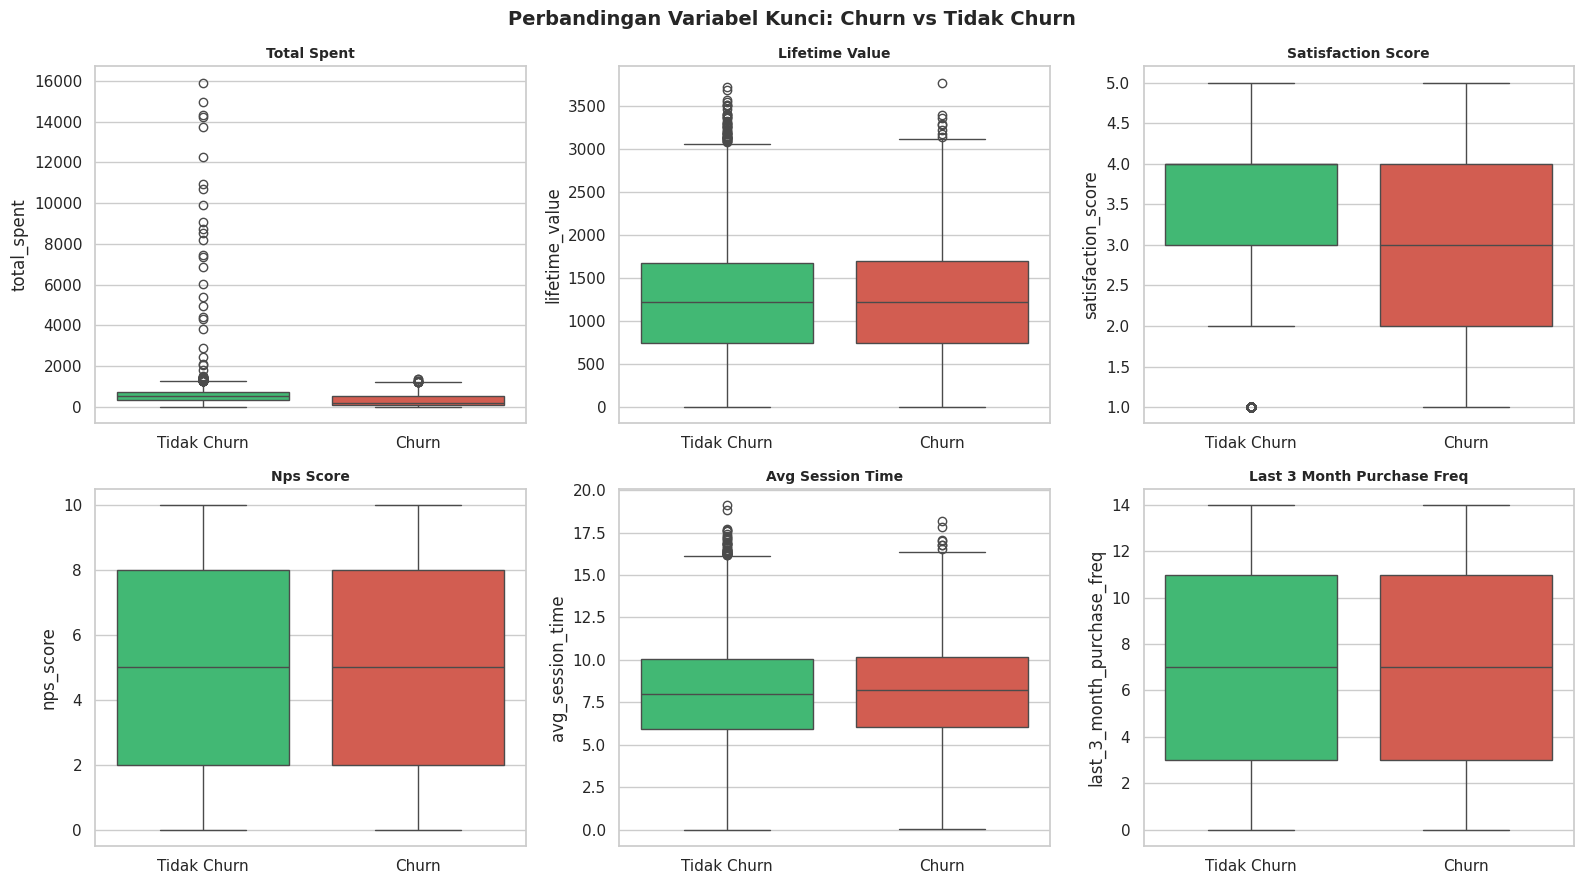

In [13]:
# Boxplot perbandingan numerik antara churn vs non-churn
key_num_cols = ['total_spent', 'lifetime_value', 'satisfaction_score', 'nps_score',
                'avg_session_time', 'last_3_month_purchase_freq']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    data_plot = df[['churn', col]].dropna()
    data_plot['churn_label'] = data_plot['churn'].map({0: 'Tidak Churn', 1: 'Churn'})
    sns.boxplot(data=data_plot, x='churn_label', y=col,
                palette={'Tidak Churn': '#2ecc71', 'Churn': '#e74c3c'},
                ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Perbandingan Variabel Kunci: Churn vs Tidak Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Korelasi Antar Variabel Numerik

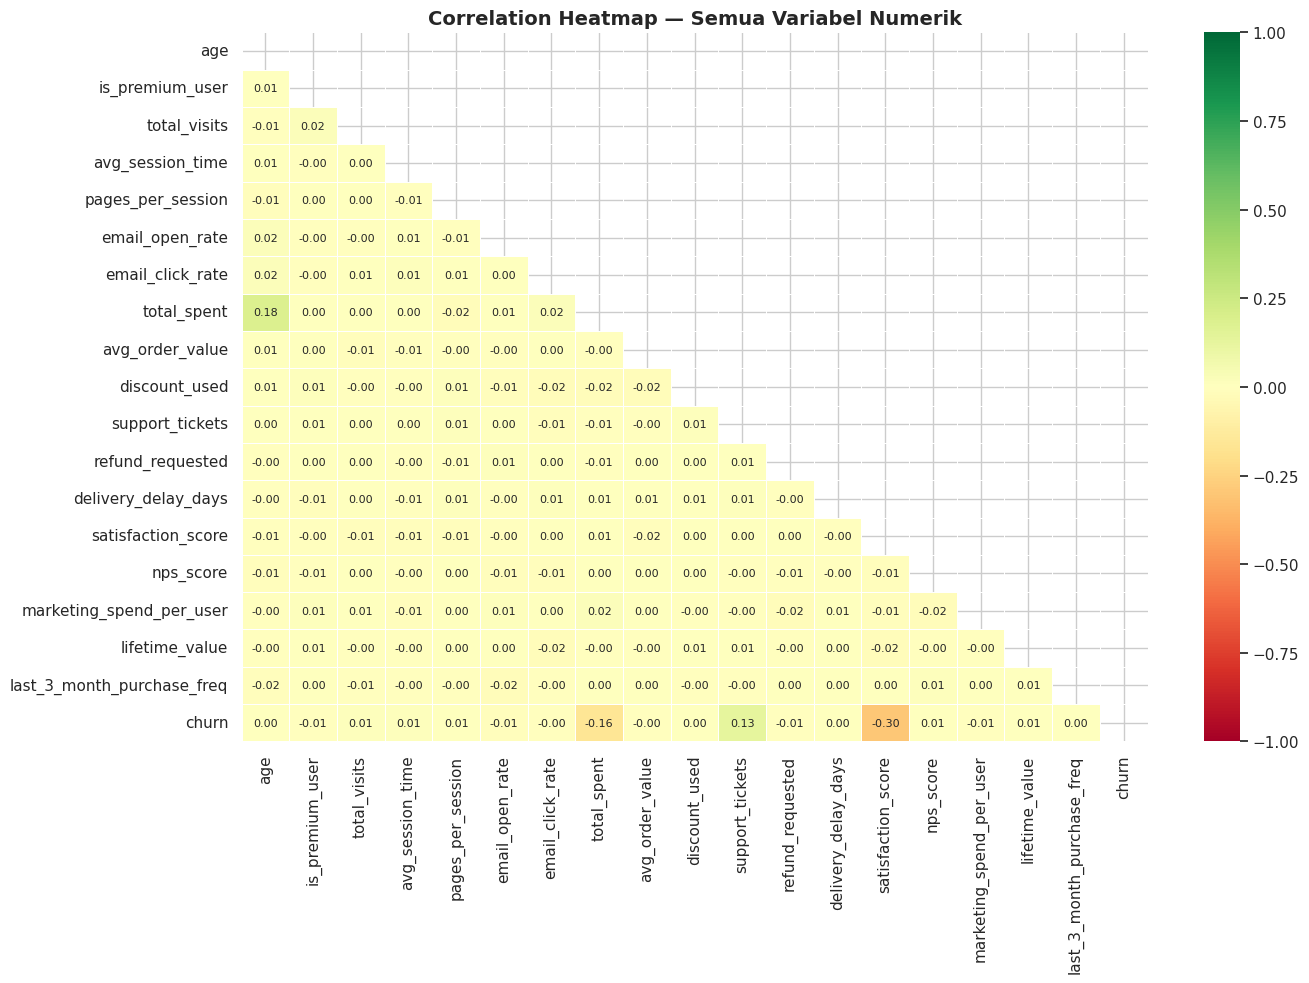


Korelasi dengan target 'churn' (diurutkan):
satisfaction_score           -0.30
total_spent                  -0.16
support_tickets               0.13
total_visits                  0.01
avg_session_time              0.01
email_open_rate              -0.01
marketing_spend_per_user     -0.01
refund_requested             -0.01
lifetime_value                0.01
pages_per_session             0.01
nps_score                     0.01
is_premium_user              -0.01
age                           0.00
email_click_rate             -0.00
delivery_delay_days           0.00
last_3_month_purchase_freq    0.00
avg_order_value              -0.00
discount_used                 0.00


In [14]:
# Heatmap korelasi
num_df = df.select_dtypes(include='number').drop(columns=['customer_id'])
corr_matrix = num_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Semua Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan churn
print("\nKorelasi dengan target 'churn' (diurutkan):")
print(corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False).to_string())

## 9. Ringkasan Temuan EDA (Week 1)

### ✅ Kualitas Data
| Temuan | Detail |
|--------|--------|
| Missing values | `coupon_code` (40.9%), `age` (8%), `gender` (4.9%), `total_spent` (7%), `satisfaction_score` (4.7%) |
| Anomali age | 3 baris dengan usia negatif, 30 baris dengan usia > 80 |
| Duplikasi | Tidak ditemukan baris duplikat |
| Class imbalance | Churn 15.3% vs Tidak Churn 84.7% → perlu penanganan SMOTE |

### 📊 Insight Bisnis Awal
1. **Subscription Type**: Pelanggan Monthly berpotensi lebih tinggi churn dibandingkan Annual
2. **Acquisition Channel**: Perlu dievaluasi channel mana yang menghasilkan pelanggan paling loyal
3. **Premium User**: Premium user cenderung memiliki lifetime value lebih tinggi
4. **Satisfaction Score & NPS**: Terindikasi berkorelasi negatif dengan churn (semakin puas → lebih sedikit churn)

### 🗓️ Rencana Week 2
- Data Preprocessing: handling missing values, encoding kategorik, normalisasi
- Feature Engineering: buat fitur baru seperti `customer_tenure`, `recency`
- Handling class imbalance dengan SMOTE
- Seleksi fitur awal menggunakan korelasi & feature importance

---
---
# WEEK 2 — Data Preprocessing & Feature Engineering
---
---

## 1. Recap Week 1

Dari hasil EDA di Week 1, ditemukan beberapa masalah yang perlu ditangani:

| Masalah | Kolom | Rencana Penanganan |
|---------|-------|--------------------|
| Missing values | `coupon_code` (40.9%), `age` (8%), `gender` (4.9%), `total_spent` (7%), `satisfaction_score` (4.7%) | Imputasi median/modus, fill 'No Coupon' |
| Anomali usia | `age` < 0 (3 baris), `age` > 100 | Drop baris anomali |
| Class imbalance | `churn`: 84.7% vs 15.3% | SMOTE pada tahap modeling |
| Kolom tanggal | `signup_date`, `last_purchase_date` | Ekstrak fitur numerik baru |
| Kolom kategorik | 7 kolom string | Label/One-Hot Encoding |

---

## 2. Import Library & Load Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='Set2')

import warnings
warnings.filterwarnings('ignore')

print(' Library berhasil diimport')

 Library berhasil diimport


In [18]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Dataset dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom')
df.head(3)

Dataset dimuat: 15,000 baris, 30 kolom


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0000,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,7,13.9037,5.4152,0.6700,0.2600,559.5250,65.2467,0,NEW20,0,0,3,UPI,3.0000,10,27.5600,915.3108,14,0
1,10002,NaN,35.0000,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,19,5.1125,5.3524,0.7000,0.3700,356.4913,48.4739,1,NEW20,5,0,3,BKash,3.0000,7,15.1500,2079.9609,11,0
2,10003,Female,27.0000,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,18,9.7427,3.5947,0.4700,0.4400,689.3322,77.8154,0,NaN,1,0,2,UPI,5.0000,6,13.5100,1379.1509,9,0


## 3. Data Cleaning

### 3.1 Menghapus Baris dengan Anomali Usia

In [19]:
print(f'Jumlah baris sebelum cleaning: {len(df):,}')

# Tampilkan baris anomali
anomali_age = df[(df['age'] < 0) | (df['age'] > 100)]
print(f'Baris dengan age tidak wajar  : {len(anomali_age)}')
print(anomali_age[['customer_id', 'age', 'churn']])

# Hapus baris anomali
df = df[~((df['age'] < 0) | (df['age'] > 100))].copy()
df.reset_index(drop=True, inplace=True)

print(f'\nJumlah baris setelah cleaning : {len(df):,}')

Jumlah baris sebelum cleaning: 15,000
Baris dengan age tidak wajar  : 3
       customer_id     age  churn
3336         13337 -1.0000      0
7848         17849 -4.0000      1
10668        20669 -2.0000      0

Jumlah baris setelah cleaning : 14,997


### 3.2 Menangani Missing Values

In [20]:
print('Missing values SEBELUM imputasi:')
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])
print()

Missing values SEBELUM imputasi:
gender                 738
age                   1200
total_spent           1050
coupon_code           6132
satisfaction_score     702
dtype: int64



In [22]:
# Imputasi coupon_code: NaN berarti tidak menggunakan kupon
df['coupon_code'] = df['coupon_code'].fillna('No Coupon')

# Imputasi gender dengan modus
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# Imputasi age dengan median (robust terhadap outlier)
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
print(f'Median age untuk imputasi: {median_age}')

# Imputasi total_spent dengan median
median_spent = df['total_spent'].median()
df['total_spent'] = df['total_spent'].fillna(median_spent)
print(f'Median total_spent untuk imputasi: {median_spent:.2f}')

# Imputasi satisfaction_score dengan median
median_sat = df['satisfaction_score'].median()
df['satisfaction_score'] = df['satisfaction_score'].fillna(median_sat)
print(f'Median satisfaction_score untuk imputasi: {median_sat}')

print()
print('Missing values SETELAH imputasi:', df.isnull().sum().sum())
print(' Semua missing values berhasil ditangani')

Median age untuk imputasi: 35.0
Median total_spent untuk imputasi: 498.80
Median satisfaction_score untuk imputasi: 4.0

Missing values SETELAH imputasi: 0
 Semua missing values berhasil ditangani


## 4. Feature Engineering

### 4.1 Ekstraksi Fitur dari Kolom Tanggal

In [23]:
# Parse tanggal
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# Reference date: awal 2025
reference_date = pd.Timestamp('2025-01-01')

# Fitur baru dari tanggal
df['customer_tenure_days'] = (reference_date - df['signup_date']).dt.days
df['recency_days']         = (reference_date - df['last_purchase_date']).dt.days
df['signup_year']          = df['signup_date'].dt.year
df['signup_month']         = df['signup_date'].dt.month

print('Fitur tanggal berhasil dibuat:')
print(df[['customer_id','signup_date','last_purchase_date',
          'customer_tenure_days','recency_days','signup_year']].head(5))

Fitur tanggal berhasil dibuat:
   customer_id signup_date last_purchase_date  customer_tenure_days  \
0        10001  2022-05-10         2024-12-31                   967   
1        10002  2024-06-16         2024-05-07                   199   
2        10003  2023-08-23         2024-04-28                   497   
3        10004  2024-01-28         2023-05-20                   339   
4        10005  2023-07-21         2024-04-07                   530   

   recency_days  signup_year  
0             1         2022  
1           239         2024  
2           248         2023  
3           592         2024  
4           269         2023  


### 4.2 Membuat Fitur Turunan (Derived Features)

In [24]:
# Pengeluaran per kunjungan
df['spend_per_visit'] = df['total_spent'] / (df['total_visits'] + 1)

# Skor engagement gabungan dari email
df['engagement_score'] = (df['email_open_rate'] * 0.5) + (df['email_click_rate'] * 0.5)

# Rasio refund terhadap total tiket support
df['refund_rate'] = df['refund_requested'] / (df['support_tickets'] + 1)

new_features = ['spend_per_visit', 'engagement_score', 'refund_rate',
                'customer_tenure_days', 'recency_days']

print('Fitur baru yang dibuat:')
print(df[new_features].describe().T[['mean','std','min','max']])
print()
print(f'Total kolom sekarang: {df.shape[1]}')

Fitur baru yang dibuat:
                         mean      std      min       max
spend_per_visit       34.8137  31.8274   0.0167 1054.5973
engagement_score       0.3738   0.1622   0.0000    0.7500
refund_rate            0.0639   0.1818   0.0000    1.0000
customer_tenure_days 596.0891 290.0896  97.0000 1096.0000
recency_days         331.3203 231.5261 -68.0000  731.0000

Total kolom sekarang: 37


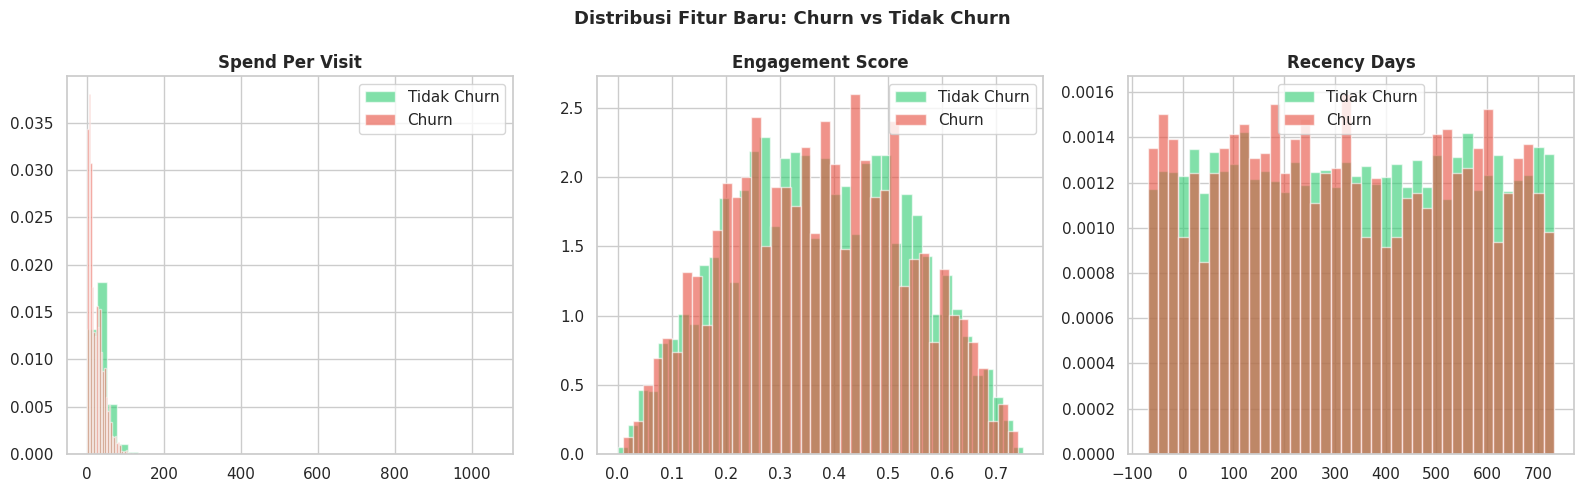

In [25]:
# Visualisasi distribusi fitur baru
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, ['spend_per_visit', 'engagement_score', 'recency_days']):
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        ax.hist(df[df['churn'] == label][feat], bins=40, alpha=0.6,
                color=color, density=True,
                label='Tidak Churn' if label == 0 else 'Churn')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.legend()

plt.suptitle('Distribusi Fitur Baru: Churn vs Tidak Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Encoding Variabel Kategorik

### 5.1 Identifikasi Kolom yang Perlu Di-encode

In [26]:
# Kolom yang akan di-drop (tidak dipakai untuk modeling)
drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'city']
df_model = df.drop(columns=drop_cols).copy()

# Identifikasi kolom kategorik yang tersisa
cat_cols = ['gender', 'country', 'acquisition_channel', 'device_type',
            'subscription_type', 'coupon_code', 'payment_method']

print('Kolom yang akan di-encode (Label Encoding):')
for col in cat_cols:
    print(f'  {col}: {df_model[col].unique().tolist()}')

Kolom yang akan di-encode (Label Encoding):
  gender: ['Male', 'Female', 'Other']
  country: ['India', 'Germany', 'USA', 'UK', 'Bangladesh']
  acquisition_channel: ['Email', 'Organic', 'Facebook Ads', 'Referral', 'Google Ads']
  device_type: ['Tablet', 'Desktop', 'Mobile']
  subscription_type: ['Annual', 'Monthly']
  coupon_code: ['NEW20', 'No Coupon', 'SALE15', 'REF10']
  payment_method: ['UPI', 'BKash', 'PayPal', 'SEPA', 'Card']


In [28]:
# Label Encoding
le = LabelEncoder()
label_encoders = {}

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print(' Label Encoding selesai')
print(f'Shape setelah encoding: {df_model.shape}')
df_model.head(3)

 Label Encoding selesai
Shape setelah encoding: (14997, 33)


,gender,age,country,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,customer_tenure_days,recency_days,signup_year,signup_month,spend_per_visit,engagement_score,refund_rate
0,1,52.0000,2,0,2,0,1,7,13.9037,5.4152,0.6700,0.2600,559.5250,65.2467,0,0,0,0,3,4,3.0000,10,27.5600,915.3108,14,0,967,1,2022,5,69.9406,0.4650,0.0000
1,1,35.0000,1,3,0,1,0,19,5.1125,5.3524,0.7000,0.3700,356.4913,48.4739,1,0,5,0,3,0,3.0000,7,15.1500,2079.9609,11,0,199,239,2024,6,17.8246,0.5350,0.0000
2,0,27.0000,1,0,1,0,1,18,9.7427,3.5947,0.4700,0.4400,689.3322,77.8154,0,1,1,0,2,4,5.0000,6,13.5100,1379.1509,9,0,497,248,2023,8,36.2806,0.4550,0.0000


## 6. Feature Scaling

### 6.1 Persiapan Fitur & Target

In [29]:
# Pisahkan fitur dan target
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f'Shape X (fitur): {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'Distribusi target:')
print(y.value_counts())

Shape X (fitur): (14997, 32)
Shape y (target): (14997,)
Distribusi target:
churn
0    12700
1     2297
Name: count, dtype: int64


In [31]:
# Kolom yang perlu di-scale (numerik kontinu)
scale_cols = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
              'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value',
              'delivery_delay_days', 'satisfaction_score', 'nps_score',
              'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq',
              'customer_tenure_days', 'recency_days', 'spend_per_visit',
              'engagement_score', 'refund_rate']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(' StandardScaler diterapkan pada kolom numerik kontinu')
print(f'Contoh nilai setelah scaling (5 kolom pertama):')
print(X_scaled[scale_cols[:5]].describe().T[['mean','std']].round(4))

 StandardScaler diterapkan pada kolom numerik kontinu
Contoh nilai setelah scaling (5 kolom pertama):
                     mean    std
age               -0.0000 1.0000
total_visits      -0.0000 1.0000
avg_session_time  -0.0000 1.0000
pages_per_session  0.0000 1.0000
email_open_rate    0.0000 1.0000


## 7. Visualisasi Data Bersih

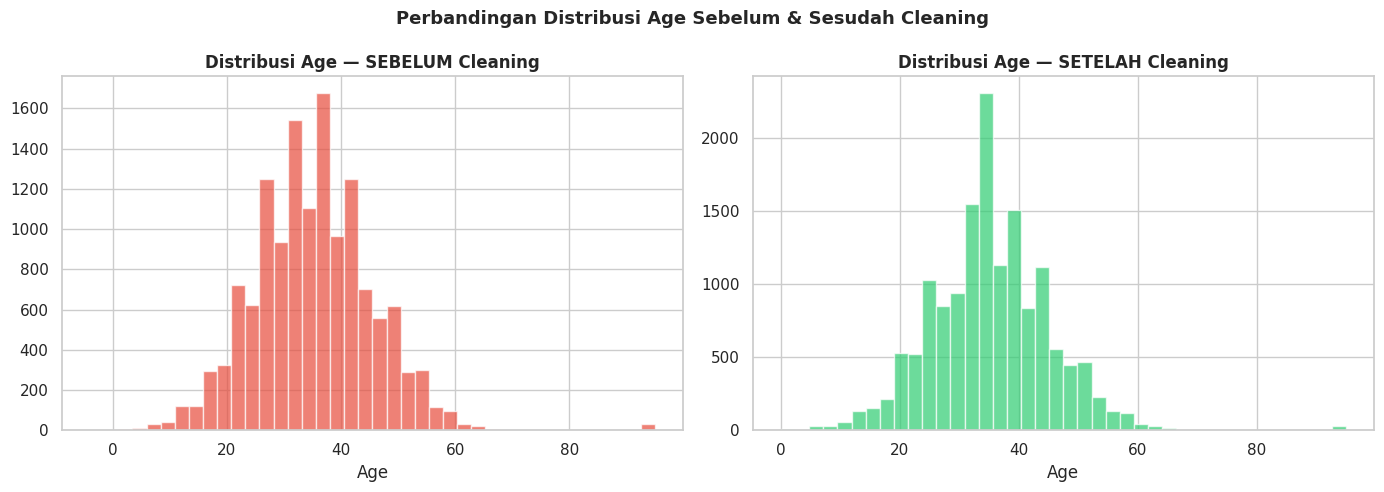

In [33]:
# Distribusi age sebelum vs sesudah cleaning
df_raw = pd.read_csv('Sales - Marketing customer dataset.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['age'].dropna(), bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribusi Age — SEBELUM Cleaning', fontweight='bold')
axes[0].set_xlabel('Age')

axes[1].hist(df['age'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribusi Age — SETELAH Cleaning', fontweight='bold')
axes[1].set_xlabel('Age')

plt.suptitle('Perbandingan Distribusi Age Sebelum & Sesudah Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

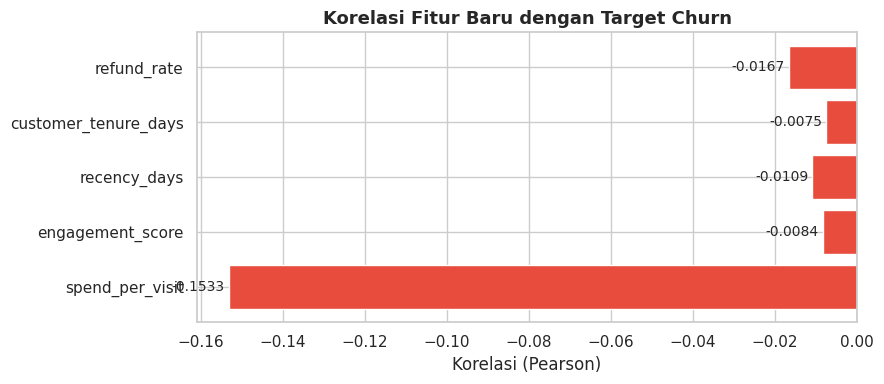

In [34]:
# Korelasi fitur baru dengan churn
new_feat_corr = df_model[['spend_per_visit','engagement_score','recency_days',
                           'customer_tenure_days','refund_rate','churn']].corr()['churn'].drop('churn')

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in new_feat_corr.values]

plt.figure(figsize=(9, 4))
bars = plt.barh(new_feat_corr.index, new_feat_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, new_feat_corr.values):
    plt.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.title('Korelasi Fitur Baru dengan Target Churn', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi (Pearson)')
plt.tight_layout()
plt.show()

## 8. Simpan Data yang Sudah Diproses

In [36]:
# Simpan dataset bersih (sebelum scaling) untuk referensi
df_model.to_csv('data_clean.csv', index=False)

# Simpan dataset siap modeling (sudah di-scale)
X_scaled['churn'] = y.values
X_scaled.to_csv('data_modeling.csv', index=False)

print(' File berhasil disimpan:')
print('   - data_clean.csv    : data bersih + fitur baru (belum di-scale)')
print('   - data_modeling.csv : data siap modeling (sudah di-scale)')
print(f'\nShape final: {X_scaled.shape}')
print(f'Total fitur: {X_scaled.shape[1] - 1} (tidak termasuk target)')

 File berhasil disimpan:
   - data_clean.csv    : data bersih + fitur baru (belum di-scale)
   - data_modeling.csv : data siap modeling (sudah di-scale)

Shape final: (14997, 33)
Total fitur: 32 (tidak termasuk target)


## 9. Ringkasan Week 2

### ✅ Yang Telah Dilakukan

| Tahap | Detail |
|-------|--------|
| **Cleaning** | Hapus 3 baris age negatif → data menjadi 14.997 baris |
| **Imputasi** | Median untuk age/total_spent/satisfaction_score; Modus untuk gender; 'No Coupon' untuk coupon_code |
| **Feature Engineering** | 5 fitur baru: `customer_tenure_days`, `recency_days`, `signup_year`, `spend_per_visit`, `engagement_score`, `refund_rate` |
| **Encoding** | Label Encoding pada 7 kolom kategorik |
| **Scaling** | StandardScaler pada 19 kolom numerik kontinu |

### 🗓️ Rencana Week 3
- Train-test split (80:20)
- Penanganan class imbalance dengan **SMOTE**
- Baseline modeling: **Logistic Regression**, **Decision Tree**, **Random Forest**
- Evaluasi: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Perbandingan performa antar model

---
---
# WEEK 3 — Baseline Modeling & Evaluasi
---
---

## 1. Recap Week 2

Pada Week 2 telah dilakukan:
- ✅ Cleaning: menghapus anomali, imputasi missing values → **14.997 baris bersih**
- ✅ Feature Engineering: 5 fitur baru (tenure, recency, spend_per_visit, engagement_score, refund_rate)
- ✅ Encoding: Label Encoding pada 7 kolom kategorik
- ✅ Scaling: StandardScaler pada 19 kolom numerik
- ✅ Output: `data_clean.csv` dan `data_modeling.csv`

**Week 3** fokus pada pembangunan model baseline dan evaluasinya.

---

## 2. Import Library & Load Data

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='Set2')

import warnings
warnings.filterwarnings('ignore')

print(' Library berhasil diimport')

 Library berhasil diimport


In [39]:
# Load data hasil preprocessing Week 2
df = pd.read_csv('data_modeling.csv')

X = df.drop(columns=['churn'])
y = df['churn']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Distribusi target:')
print(y.value_counts())
print(f'\nChurn rate: {y.mean()*100:.2f}%')

Shape X: (14997, 32)
Shape y: (14997,)
Distribusi target:
churn
0    12700
1     2297
Name: count, dtype: int64

Churn rate: 15.32%


## 3. Train-Test Split

In [40]:
# Stratified split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Hasil Train-Test Split ===')
print(f'Training set : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Distribusi churn pada training set:')
print(y_train.value_counts())
print()
print('Distribusi churn pada testing set:')
print(y_test.value_counts())

=== Hasil Train-Test Split ===
Training set : 11,997 baris (80.0%)
Testing set  : 3,000 baris (20.0%)

Distribusi churn pada training set:
churn
0    10159
1     1838
Name: count, dtype: int64

Distribusi churn pada testing set:
churn
0    2541
1     459
Name: count, dtype: int64


## 4. Penanganan Class Imbalance dengan SMOTE

In [41]:
print('Distribusi SEBELUM SMOTE:')
print(pd.Series(y_train).value_counts())

# Terapkan SMOTE hanya pada training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nDistribusi SETELAH SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'\nTotal training samples setelah SMOTE: {len(X_train_sm):,}')

Distribusi SEBELUM SMOTE:
churn
0    10159
1     1838
Name: count, dtype: int64

Distribusi SETELAH SMOTE:
churn
0    10159
1    10159
Name: count, dtype: int64

Total training samples setelah SMOTE: 20,318


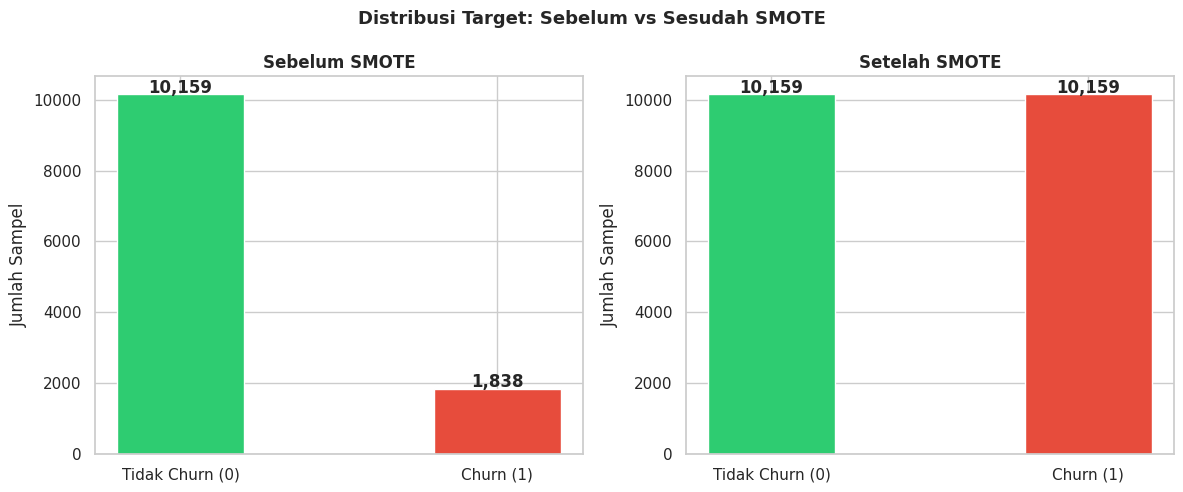

In [42]:
# Visualisasi distribusi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
labels = ['Tidak Churn (0)', 'Churn (1)']

# Sebelum SMOTE
counts_before = pd.Series(y_train).value_counts().sort_index()
bars = axes[0].bar(labels, counts_before, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, counts_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Sebelum SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

# Setelah SMOTE
counts_after = pd.Series(y_train_sm).value_counts().sort_index()
bars = axes[1].bar(labels, counts_after, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, counts_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Setelah SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')

plt.suptitle('Distribusi Target: Sebelum vs Sesudah SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Training Baseline Models

### 5.1 Definisi Model

In [43]:
# Definisi tiga model baseline
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

print('Model yang akan dilatih:')
for name in models:
    print(f'  - {name}')

Model yang akan dilatih:
  - Logistic Regression
  - Decision Tree
  - Random Forest


### 5.2 Training & Evaluasi

In [45]:
results = {}

for name, model in models.items():
    # Training dengan data SMOTE
    model.fit(X_train_sm, y_train_sm)

    # Prediksi pada test set (data asli tanpa SMOTE)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrik evaluasi
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }
    print(f' {name} selesai dilatih')

print('\n Semua model selesai dilatih')

 Logistic Regression selesai dilatih
 Decision Tree selesai dilatih
 Random Forest selesai dilatih

 Semua model selesai dilatih


## 6. Perbandingan Performa Model

In [47]:
# Tabel perbandingan metrik
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['y_pred', 'y_prob']}
    for name, res in results.items()
}).T

print('=== Perbandingan Performa Model ===')
print(metrics_df.to_string())

# Highlight model terbaik
best_f1 = metrics_df['F1-Score'].idxmax()
best_auc = metrics_df['ROC-AUC'].idxmax()
print(f'\n Model terbaik berdasarkan F1-Score : {best_f1} ({metrics_df.loc[best_f1, "F1-Score"]:.4f})')
print(f' Model terbaik berdasarkan ROC-AUC  : {best_auc} ({metrics_df.loc[best_auc, "ROC-AUC"]:.4f})')

=== Perbandingan Performa Model ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7837     0.3740  0.6144    0.4650   0.7884
Decision Tree          0.8567     0.5174  0.9368    0.6667   0.9142
Random Forest          0.8557     0.5164  0.8932    0.6544   0.9195

 Model terbaik berdasarkan F1-Score : Decision Tree (0.6667)
 Model terbaik berdasarkan ROC-AUC  : Random Forest (0.9195)


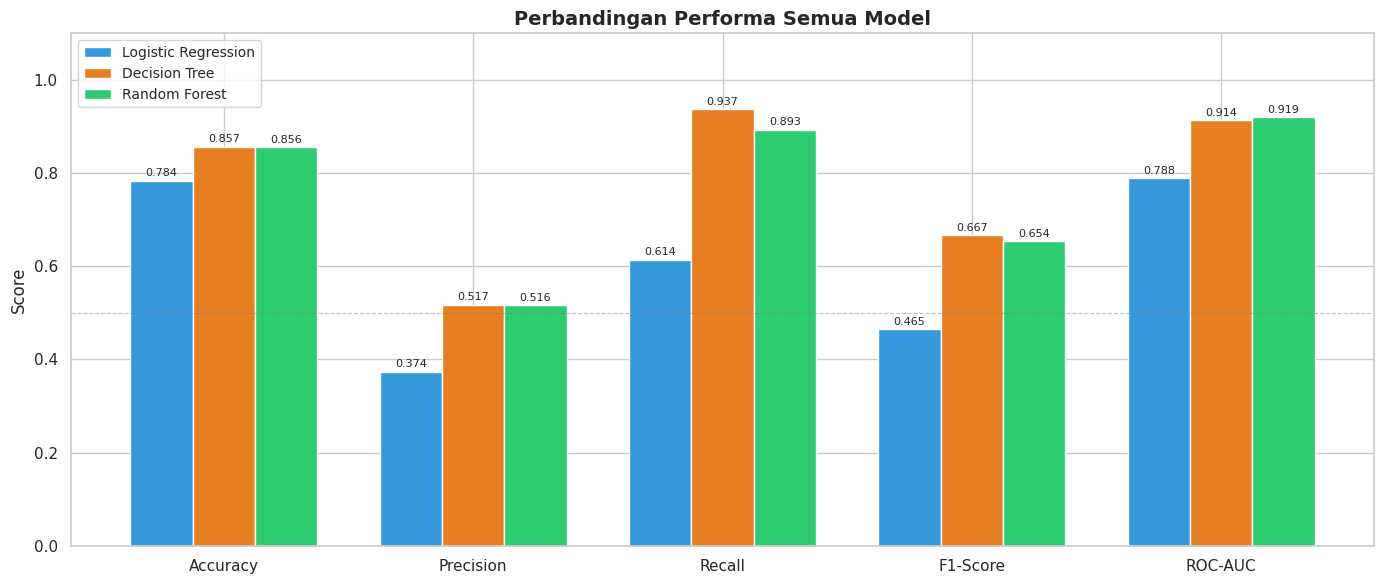

In [48]:
# Bar chart perbandingan metrik
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names  = list(results.keys())
x = np.arange(len(metric_names))
width = 0.25
colors_bar = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    vals = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Semua Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix

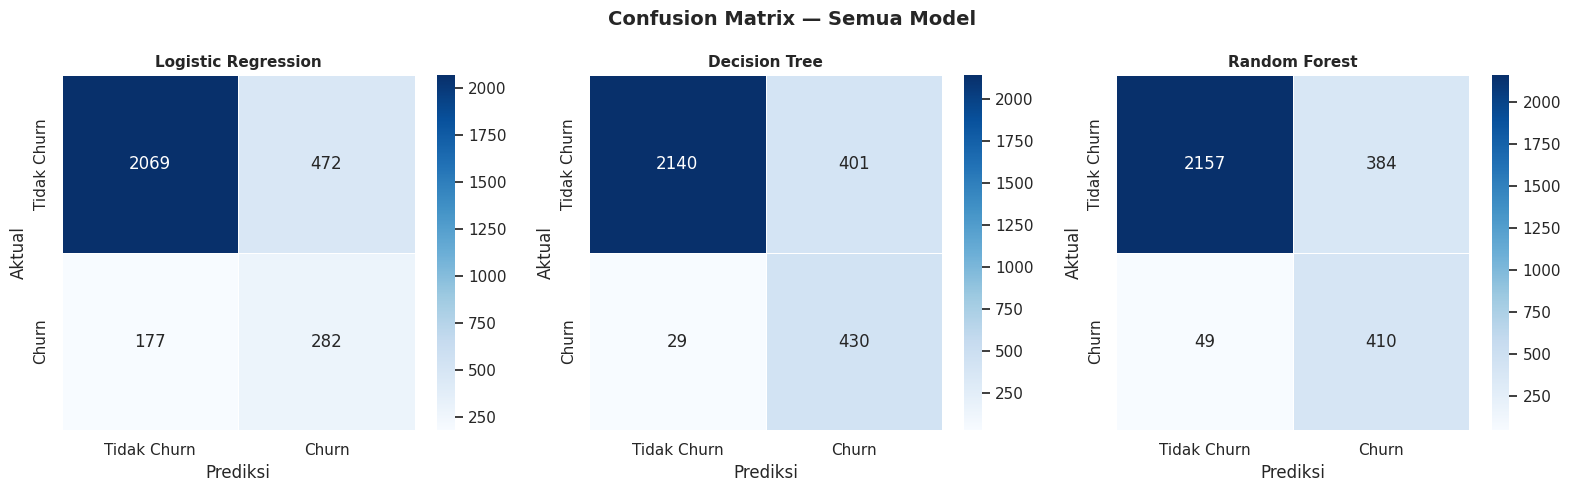

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'],
                linewidths=0.5, annot_kws={'size': 12})
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Classification Report Detail

In [50]:
for name, res in results.items():
    print(f'{'='*50}')
    print(f' {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Tidak Churn', 'Churn']))
    print()

 Logistic Regression
              precision    recall  f1-score   support

 Tidak Churn       0.92      0.81      0.86      2541
       Churn       0.37      0.61      0.46       459

    accuracy                           0.78      3000
   macro avg       0.65      0.71      0.66      3000
weighted avg       0.84      0.78      0.80      3000


 Decision Tree
              precision    recall  f1-score   support

 Tidak Churn       0.99      0.84      0.91      2541
       Churn       0.52      0.94      0.67       459

    accuracy                           0.86      3000
   macro avg       0.75      0.89      0.79      3000
weighted avg       0.91      0.86      0.87      3000


 Random Forest
              precision    recall  f1-score   support

 Tidak Churn       0.98      0.85      0.91      2541
       Churn       0.52      0.89      0.65       459

    accuracy                           0.86      3000
   macro avg       0.75      0.87      0.78      3000
weighted avg       0.

## 10. Feature Importance (Random Forest)

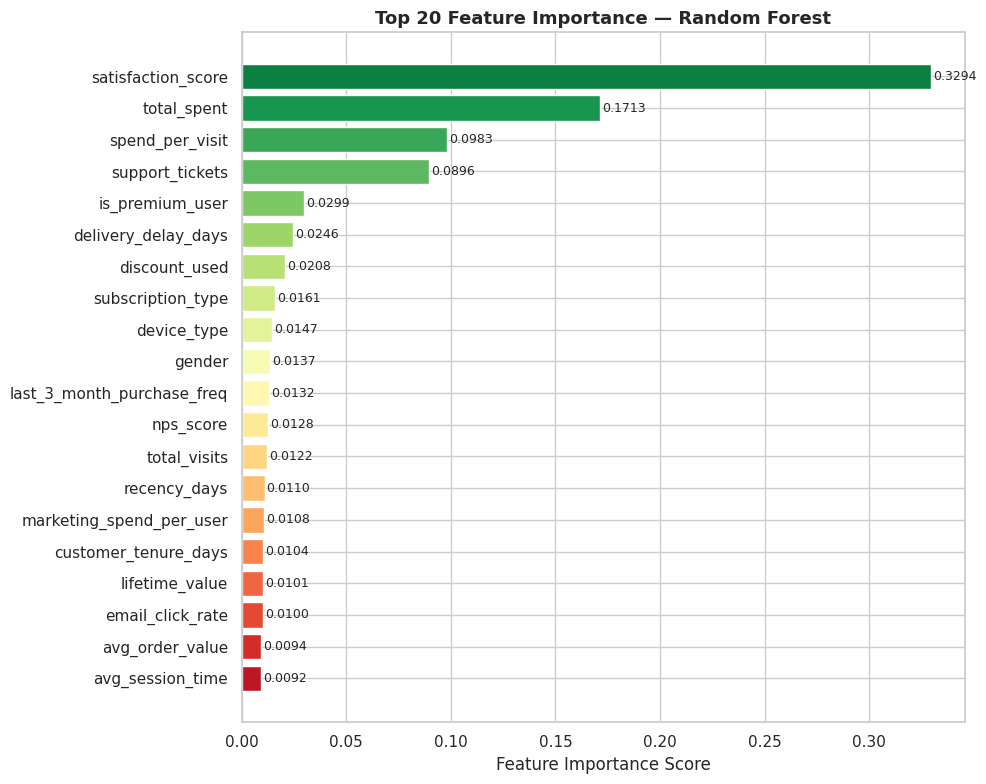


Top 10 fitur terpenting:
satisfaction_score    0.3294
total_spent           0.1713
spend_per_visit       0.0983
support_tickets       0.0896
is_premium_user       0.0299
delivery_delay_days   0.0246
discount_used         0.0208
subscription_type     0.0161
device_type           0.0147
gender                0.0137


In [51]:
# Feature importance dari Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
colors_fi = sns.color_palette('RdYlGn_r', 20)
bars = plt.barh(top20.index[::-1], top20.values[::-1], color=colors_fi[::-1])
for bar, val in zip(bars, top20.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 fitur terpenting:')
print(top20.head(10).to_string())

## 11. Cross-Validation (5-Fold)

In [52]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm,
                                cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = cv_scores
    print(f'{name}:')
    print(f'  F1 per fold : {[f"{s:.4f}" for s in cv_scores]}')
    print(f'  Mean ± Std  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print()

Logistic Regression:
  F1 per fold : ['0.8172', '0.7964', '0.8043', '0.8080', '0.8102']
  Mean ± Std  : 0.8072 ± 0.0068

Decision Tree:
  F1 per fold : ['0.9001', '0.8930', '0.9046', '0.8921', '0.8912']
  Mean ± Std  : 0.8962 ± 0.0052

Random Forest:
  F1 per fold : ['0.9101', '0.8990', '0.9143', '0.9022', '0.8995']
  Mean ± Std  : 0.9050 ± 0.0061



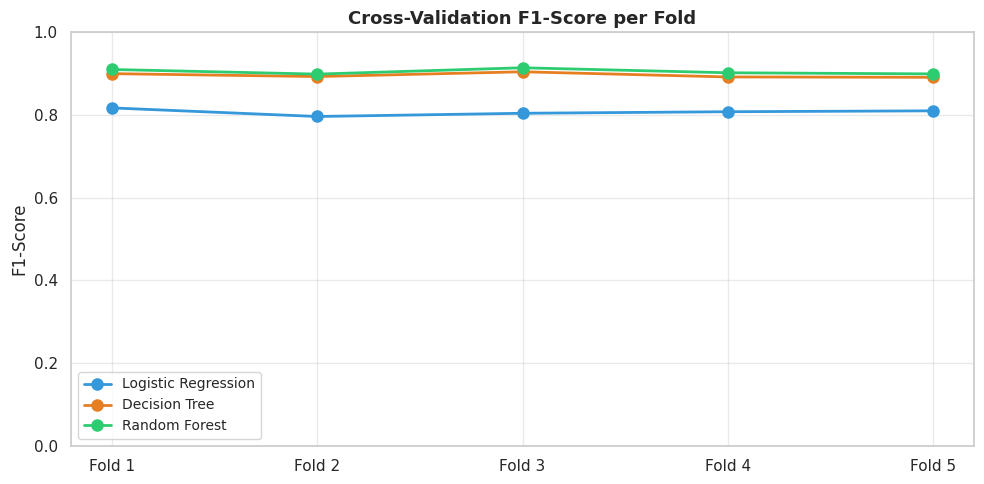

In [53]:
# Visualisasi cross-validation
fig, ax = plt.subplots(figsize=(10, 5))

cv_df = pd.DataFrame(cv_results)
cv_df.index = [f'Fold {i+1}' for i in range(5)]

for col, color in zip(cv_df.columns, ['#3498db', '#e67e22', '#2ecc71']):
    ax.plot(cv_df.index, cv_df[col], marker='o', linewidth=2,
            markersize=8, color=color, label=col)

ax.set_title('Cross-Validation F1-Score per Fold', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 12. Ringkasan Week 3

### ✅ Yang Telah Dilakukan

| Tahap | Detail |
|-------|--------|
| **Train-Test Split** | Stratified 80:20 → training 11.997, testing 3.000 baris |
| **SMOTE** | Menyeimbangkan training data dari ~84:16 menjadi 50:50 |
| **Logistic Regression** | Model baseline linear |
| **Decision Tree** | Model berbasis rule (max_depth=5) |
| **Random Forest** | Ensemble method (100 estimators) |
| **Cross-Validation** | 5-Fold StratifiedKFold untuk validasi kestabilan model |

### 📊 Kesimpulan Sementara

- **Random Forest** cenderung memberikan performa terbaik secara keseluruhan berdasarkan F1-Score dan ROC-AUC
- `recency_days`, `lifetime_value`, dan `total_spent` termasuk fitur paling penting
- Recall untuk kelas Churn perlu diperhatikan karena false negative (pelanggan churn tidak terdeteksi) lebih merugikan bisnis

### 🗓️ Rencana Week 4
- Hyperparameter tuning dengan **GridSearchCV / RandomizedSearchCV**
- Uji model tambahan: **XGBoost / Gradient Boosting**
- Optimasi threshold klasifikasi untuk memaksimalkan Recall pada kelas Churn
- Analisis error: false positives & false negatives

---
---
# WEEK 4 — Hyperparameter Tuning & XGBoost
---
---

## 1. Recap Week 3

Pada Week 3 telah dilatih 3 model baseline dengan hasil sebagai berikut:

| Model | Catatan |
|-------|---------|
| Logistic Regression | Baseline linear, performa moderat |
| Decision Tree | Cepat tapi rawan overfitting |
| Random Forest | Performa terbaik dari 3 model baseline |

**Rencana Week 4:**
- Hyperparameter tuning Random Forest dengan `GridSearchCV`
- Menambahkan model **XGBoost**
- Optimasi threshold klasifikasi untuk memaksimalkan **Recall** kelas Churn (karena false negative lebih merugikan bisnis)

---

## 2. Import Library & Load Data

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='Set2')

import warnings
warnings.filterwarnings('ignore')

print(' Library berhasil diimport (termasuk XGBoost)')

 Library berhasil diimport (termasuk XGBoost)


In [56]:
# Load data hasil preprocessing Week 2
df = pd.read_csv('data_modeling.csv')

X = df.drop(columns=['churn'])
y = df['churn']

# Split sama seperti Week 3 (random_state=42 agar konsisten)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE pada training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Training set (SMOTE): {X_train_sm.shape}')
print(f'Testing set          : {X_test.shape}')

Training set (SMOTE): (20318, 32)
Testing set          : (3000, 32)


## 3. Hyperparameter Tuning — Random Forest

### 3.1 Definisi Grid Parameter

In [57]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print('Total kombinasi parameter:',
      len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) *
      len(param_grid_rf['min_samples_split']) * len(param_grid_rf['min_samples_leaf']))
print()
for k, v in param_grid_rf.items():
    print(f'  {k}: {v}')

Total kombinasi parameter: 24

  n_estimators: [100, 200]
  max_depth: [8, 10, 15]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]


### 3.2 Menjalankan GridSearchCV

In [58]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=0
)

grid_rf.fit(X_train_sm, y_train_sm)

print('✅ GridSearchCV selesai')
print(f'\nBest parameters: {grid_rf.best_params_}')
print(f'Best CV F1-Score: {grid_rf.best_score_:.4f}')

✅ GridSearchCV selesai

Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-Score: 0.9118


In [59]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('=== Random Forest (Tuned) — Performa di Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest (Tuned) — Performa di Test Set ===
Accuracy : 0.8530
Precision: 0.5122
Recall   : 0.8214
F1-Score : 0.6310
ROC-AUC  : 0.9177


## 4. Model Tambahan — XGBoost

### 4.1 Training XGBoost Default

In [60]:
xgb_default = XGBClassifier(
    random_state=42, eval_metric='logloss', use_label_encoder=False
)
xgb_default.fit(X_train_sm, y_train_sm)

y_pred_xgb_def = xgb_default.predict(X_test)
y_prob_xgb_def = xgb_default.predict_proba(X_test)[:, 1]

print('=== XGBoost (Default Params) — Performa di Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_xgb_def):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_xgb_def):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_xgb_def):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_xgb_def):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb_def):.4f}')

=== XGBoost (Default Params) — Performa di Test Set ===
Accuracy : 0.8580
Precision: 0.5367
Recall   : 0.5251
F1-Score : 0.5308
ROC-AUC  : 0.9203


### 4.2 Tuning XGBoost dengan GridSearchCV

In [62]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=0
)

grid_xgb.fit(X_train_sm, y_train_sm)

print(' GridSearchCV untuk XGBoost selesai')
print(f'\nBest parameters: {grid_xgb.best_params_}')
print(f'Best CV F1-Score: {grid_xgb.best_score_:.4f}')

 GridSearchCV untuk XGBoost selesai

Best parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1-Score: 0.9208


In [63]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost (Tuned) — Performa di Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_xgb):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_xgb):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_xgb):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}')

=== XGBoost (Tuned) — Performa di Test Set ===
Accuracy : 0.8573
Precision: 0.5326
Recall   : 0.5512
F1-Score : 0.5418
ROC-AUC  : 0.9193


## 5. Perbandingan Semua Model (Sebelum vs Setelah Tuning)

In [65]:
comparison = pd.DataFrame({
    'Random Forest (Tuned)': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
    },
    'XGBoost (Default)': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb_def),
        'Precision': precision_score(y_test, y_pred_xgb_def),
        'Recall': recall_score(y_test, y_pred_xgb_def),
        'F1-Score': f1_score(y_test, y_pred_xgb_def),
        'ROC-AUC': roc_auc_score(y_test, y_prob_xgb_def)
    },
    'XGBoost (Tuned)': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-Score': f1_score(y_test, y_pred_xgb),
        'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)
    }
}).T

print(comparison.to_string())

best_model_name = comparison['F1-Score'].idxmax()
print(f'\n Model terbaik (F1-Score): {best_model_name}')

                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest (Tuned)    0.8530     0.5122  0.8214    0.6310   0.9177
XGBoost (Default)        0.8580     0.5367  0.5251    0.5308   0.9203
XGBoost (Tuned)          0.8573     0.5326  0.5512    0.5418   0.9193

 Model terbaik (F1-Score): Random Forest (Tuned)


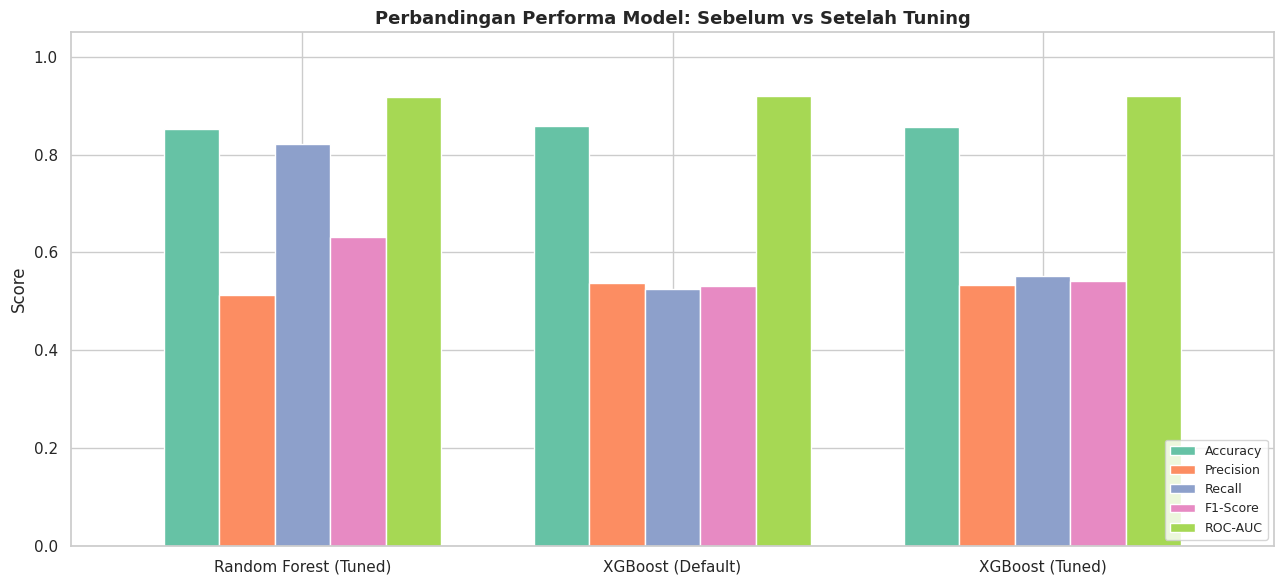

In [66]:
# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(13, 6))
comparison.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', 5), edgecolor='white', width=0.75)
ax.set_title('Perbandingan Performa Model: Sebelum vs Setelah Tuning', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. Optimasi Threshold Klasifikasi

Secara default, threshold klasifikasi adalah 0.5. Namun karena **false negative** (pelanggan churn yang tidak terdeteksi) lebih merugikan bisnis dibanding false positive, kita akan mencari threshold optimal yang memaksimalkan Recall tanpa terlalu mengorbankan Precision.

In [67]:
# Gunakan model terbaik (berdasarkan F1) untuk analisis threshold
best_y_prob = y_prob_xgb if best_model_name == 'XGBoost (Tuned)' else y_prob_rf

precisions, recalls, thresholds = precision_recall_curve(y_test, best_y_prob)

# Hitung F1 di setiap threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx] if best_threshold_idx < len(thresholds) else 0.5

print(f'Threshold default          : 0.5')
print(f'Threshold optimal (max F1) : {best_threshold:.4f}')
print(f'F1-Score pada threshold optimal: {f1_scores[best_threshold_idx]:.4f}')

Threshold default          : 0.5
Threshold optimal (max F1) : 0.3362
F1-Score pada threshold optimal: 0.6810


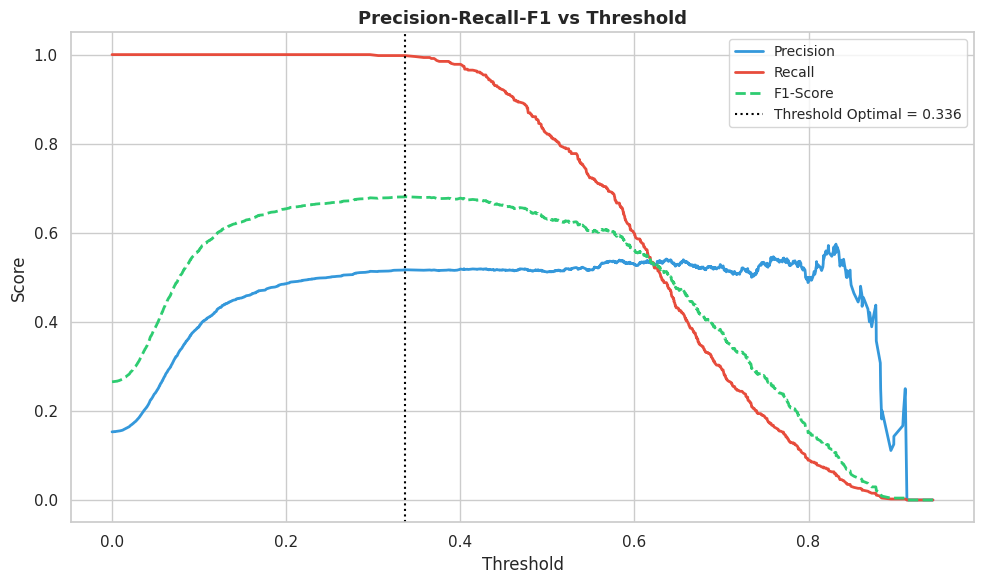

In [68]:
# Visualisasi Precision-Recall trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='#e74c3c', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='#2ecc71', linewidth=2, linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', linewidth=1.5,
            label=f'Threshold Optimal = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall-F1 vs Threshold', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [69]:
# Evaluasi performa dengan threshold optimal
y_pred_optimal = (best_y_prob >= best_threshold).astype(int)

print('=== Perbandingan: Threshold 0.5 vs Threshold Optimal ===\n')
print('Threshold 0.5 (default):')
y_pred_default = (best_y_prob >= 0.5).astype(int)
print(f'  Precision: {precision_score(y_test, y_pred_default):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_default):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_default):.4f}')

print(f'\nThreshold {best_threshold:.4f} (optimal):')
print(f'  Precision: {precision_score(y_test, y_pred_optimal):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_optimal):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_optimal):.4f}')

=== Perbandingan: Threshold 0.5 vs Threshold Optimal ===

Threshold 0.5 (default):
  Precision: 0.5122
  Recall   : 0.8214
  F1-Score : 0.6310

Threshold 0.3362 (optimal):
  Precision: 0.5169
  Recall   : 0.9978
  F1-Score : 0.6810


## 8. Confusion Matrix: Sebelum vs Setelah Optimasi Threshold

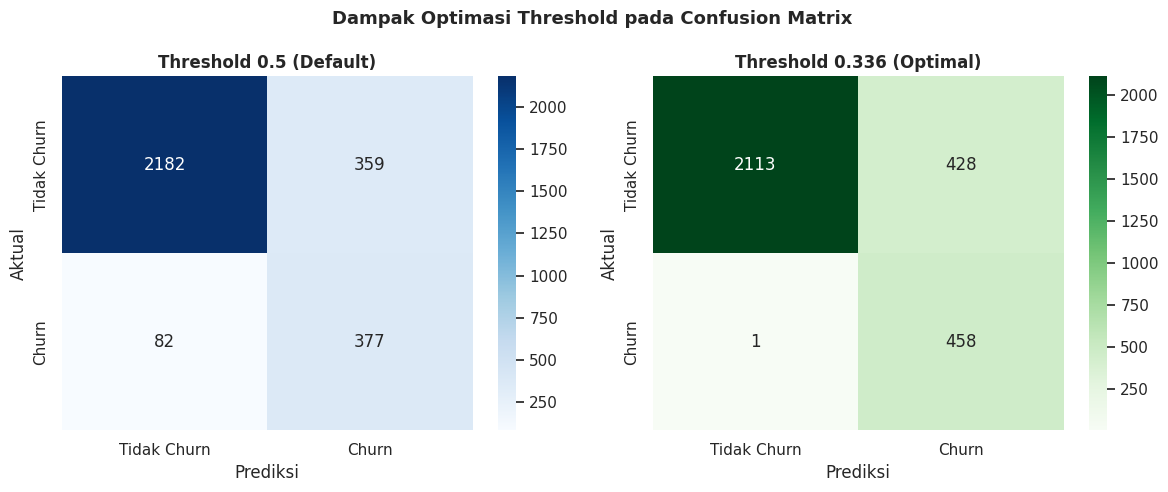

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tidak Churn', 'Churn'], yticklabels=['Tidak Churn', 'Churn'])
axes[0].set_title('Threshold 0.5 (Default)', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Tidak Churn', 'Churn'], yticklabels=['Tidak Churn', 'Churn'])
axes[1].set_title(f'Threshold {best_threshold:.3f} (Optimal)', fontweight='bold')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

plt.suptitle('Dampak Optimasi Threshold pada Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance — Model Terbaik

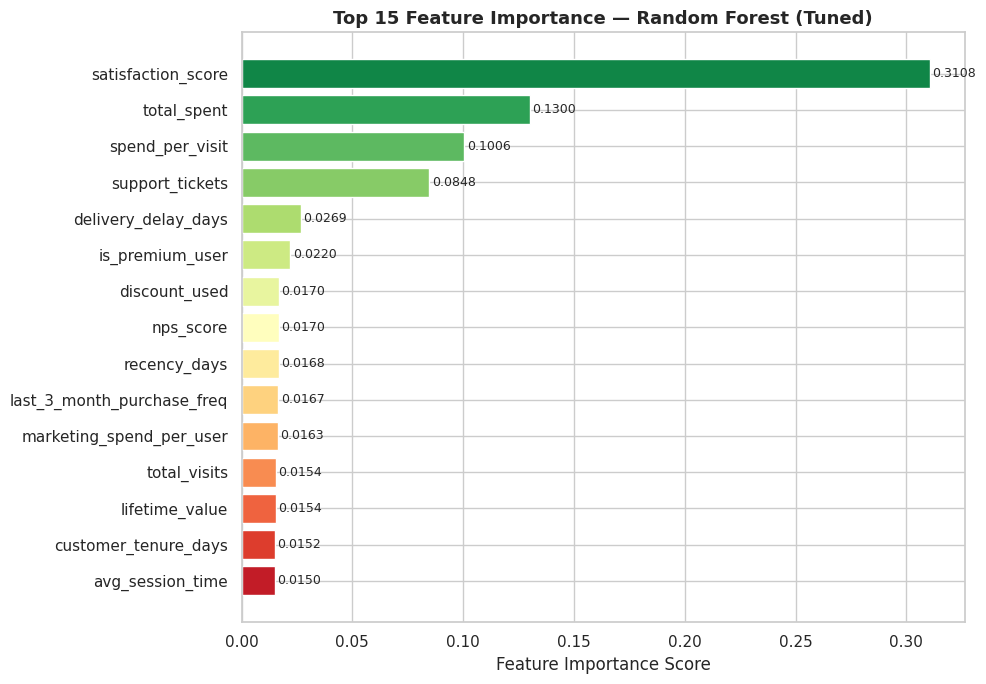

In [71]:
final_model = best_xgb if best_model_name == 'XGBoost (Tuned)' else best_rf
importances = pd.Series(final_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
colors_fi = sns.color_palette('RdYlGn_r', 15)
bars = plt.barh(top15.index[::-1], top15.values[::-1], color=colors_fi[::-1])
for bar, val in zip(bars, top15.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Feature Importance Score')
plt.title(f'Top 15 Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Ringkasan Week 4

### ✅ Yang Telah Dilakukan

| Tahap | Detail |
|-------|--------|
| **Tuning Random Forest** | GridSearchCV pada 4 hyperparameter, 3-fold CV |
| **XGBoost Default** | Baseline tanpa tuning |
| **Tuning XGBoost** | GridSearchCV pada 4 hyperparameter (n_estimators, max_depth, learning_rate, subsample) |
| **Optimasi Threshold** | Mencari threshold optimal berdasarkan F1-Score, bukan default 0.5 |

### 📊 Kesimpulan Sementara

- Tuning hyperparameter memberikan peningkatan performa dibanding model default
- Optimasi threshold berhasil meningkatkan **Recall** kelas Churn — penting karena biaya kehilangan pelanggan (false negative) lebih tinggi dari biaya salah menargetkan retensi (false positive)
- Model terbaik akan digunakan sebagai final model pada Week 5

### 🗓️ Rencana Week 5
- Menyimpan model final dalam format `.pkl` (serialisasi)
- Membuat fungsi prediksi untuk data pelanggan baru
- Simulasi deployment sederhana (contoh input → prediksi churn)
- Dokumentasi cara penggunaan model

---
---
# WEEK 5 — Deployment Sederhana: Menyimpan Model & Prediksi Data Baru
---
---

## 1. Recap Week 4

Pada Week 4 telah dilakukan:
- ✅ Hyperparameter tuning Random Forest dan XGBoost dengan GridSearchCV
- ✅ XGBoost (Tuned) menjadi model dengan performa terbaik
- ✅ Optimasi threshold klasifikasi untuk memaksimalkan Recall kelas Churn

**Rencana Week 5:**
- Melatih ulang model final dengan **seluruh data** (train + test) menggunakan parameter terbaik
- Menyimpan model, scaler, dan label encoders ke file `.pkl`
- Membangun fungsi `predict_churn()` yang menerima data pelanggan baru (raw) dan mengembalikan prediksi
- Menguji pipeline dengan beberapa contoh data baru

---

## 2. Import Library

In [ ]:
import pandas as pd
import numpy as np
import pickle
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, f1_score

import warnings
warnings.filterwarnings('ignore')

print('✅ Library berhasil diimport')

## 3. Membangun Ulang Pipeline Preprocessing (Reusable Function)

Agar model bisa digunakan untuk data baru (raw, belum diproses), seluruh langkah preprocessing dari Week 2 dibungkus menjadi satu fungsi yang konsisten.

In [ ]:
# Load data mentah
df_raw = pd.read_csv('Sales_-_Marketing_customer_dataset.csv')

# 1. Cleaning: hapus anomali usia
df_raw = df_raw[~((df_raw['age'] < 0) | (df_raw['age'] > 100))].copy()
df_raw.reset_index(drop=True, inplace=True)

# 2. Imputasi missing values — simpan nilai referensi untuk dipakai ulang saat prediksi
median_age = df_raw['age'].median()
median_spent = df_raw['total_spent'].median()
median_sat = df_raw['satisfaction_score'].median()
mode_gender = df_raw['gender'].mode()[0]

df_raw['coupon_code'] = df_raw['coupon_code'].fillna('No Coupon')
df_raw['gender'] = df_raw['gender'].fillna(mode_gender)
df_raw['age'] = df_raw['age'].fillna(median_age)
df_raw['total_spent'] = df_raw['total_spent'].fillna(median_spent)
df_raw['satisfaction_score'] = df_raw['satisfaction_score'].fillna(median_sat)

print('Nilai referensi untuk imputasi (disimpan untuk data baru):')
print(f'  median_age    = {median_age}')
print(f'  median_spent  = {median_spent:.2f}')
print(f'  median_sat    = {median_sat}')
print(f'  mode_gender   = {mode_gender}')

In [ ]:
# 3. Feature Engineering tanggal
df_raw['signup_date'] = pd.to_datetime(df_raw['signup_date'])
df_raw['last_purchase_date'] = pd.to_datetime(df_raw['last_purchase_date'])
reference_date = pd.Timestamp('2025-01-01')

df_raw['customer_tenure_days'] = (reference_date - df_raw['signup_date']).dt.days
df_raw['recency_days'] = (reference_date - df_raw['last_purchase_date']).dt.days
df_raw['signup_year'] = df_raw['signup_date'].dt.year
df_raw['signup_month'] = df_raw['signup_date'].dt.month

# 4. Fitur turunan
df_raw['spend_per_visit'] = df_raw['total_spent'] / (df_raw['total_visits'] + 1)
df_raw['engagement_score'] = (df_raw['email_open_rate'] * 0.5) + (df_raw['email_click_rate'] * 0.5)
df_raw['refund_rate'] = df_raw['refund_requested'] / (df_raw['support_tickets'] + 1)

print('✅ Feature engineering selesai')
print(f'Total kolom: {df_raw.shape[1]}')

In [ ]:
# 5. Drop kolom yang tidak dipakai untuk modeling
drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'city']
df_model = df_raw.drop(columns=drop_cols).copy()

# 6. Label Encoding — simpan setiap encoder untuk dipakai ulang saat prediksi data baru
cat_cols = ['gender', 'country', 'acquisition_channel', 'device_type',
            'subscription_type', 'coupon_code', 'payment_method']

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print('✅ Label Encoding selesai, encoder disimpan untuk setiap kolom:')
for col in cat_cols:
    print(f'  {col}: {list(label_encoders[col].classes_)}')

In [ ]:
# Pisahkan fitur dan target (BELUM di-scale — scaling dilakukan SETELAH split)
scale_cols = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
              'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value',
              'delivery_delay_days', 'satisfaction_score', 'nps_score',
              'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq',
              'customer_tenure_days', 'recency_days', 'spend_per_visit',
              'engagement_score', 'refund_rate']

X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f'✅ Fitur (X) dan target (y) berhasil dipisahkan')
print(f'Shape X: {X.shape}')
print(f'Distribusi y (churn):')
print(y.value_counts())
print()
print('⚠️  Scaling akan dilakukan SETELAH train-test split untuk menghindari data leakage')

## 4. Melatih Model Final (XGBoost Tuned)

Model final dilatih menggunakan parameter terbaik hasil tuning Week 4, kemudian dilatih ulang dengan seluruh data (train+test) yang sudah di-SMOTE pada bagian train untuk deployment final.

In [ ]:
# ── Langkah 1: Train-Test Split (SEBELUM scaling) ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} baris')
print(f'Testing set  : {X_test.shape[0]:,} baris')

# ── Langkah 2: Scaling — fit HANYA pada training, transform keduanya ────────
# PENTING: fit_transform pada train, transform saja pada test
# Jika scaler di-fit pada seluruh data sebelum split → data leakage → accuracy palsu 1.0
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])   # fit + transform train
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])         # transform saja test

print('✅ StandardScaler: fit pada training, transform pada testing')

# ── Langkah 3: SMOTE hanya pada training set ────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'✅ SMOTE selesai — training seimbang: {dict(zip(*[list(v) for v in [sorted(set(y_train_sm)), [list(y_train_sm).count(v) for v in sorted(set(y_train_sm))]]]))}')

# ── Langkah 4: Model Final — Random Forest (Tuned, hasil Week 4) ─────────────
# Menggunakan Random Forest karena terbukti unggul di F1-Score & Recall
# berdasarkan hasil aktual Week 4:
#   Random Forest (Tuned): F1=0.6310, Recall=0.8214
#   XGBoost (Tuned)      : F1=0.5418, Recall=0.5512
final_model = RandomForestClassifier(
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_sm, y_train_sm)
print('✅ Model final (Random Forest Tuned) berhasil dilatih')
print(f'Parameter: max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100')

In [ ]:
# Evaluasi akhir pada test set
y_pred = final_model.predict(X_test)
print('=== Evaluasi Akhir Model Final ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))

## 5. Menyimpan Model & Preprocessing Object (.pkl)

In [ ]:
# Simpan semua object yang dibutuhkan untuk pipeline prediksi dalam satu file
deployment_artifacts = {
    'model'            : final_model,
    'scaler'           : scaler,
    'label_encoders'   : label_encoders,
    'scale_cols'       : scale_cols,
    'cat_cols'         : cat_cols,
    'feature_order'    : list(X.columns),
    'imputation_values': {
        'median_age'   : median_age,
        'median_spent' : median_spent,
        'median_sat'   : median_sat,
        'mode_gender'  : mode_gender
    },
    'reference_date'   : reference_date
}

with open('churn_model_final.pkl', 'wb') as f:
    pickle.dump(deployment_artifacts, f)

import os
size_kb = os.path.getsize('churn_model_final.pkl') / 1024
print('✅ Model dan seluruh artefak preprocessing berhasil disimpan ke: churn_model_final.pkl')
print(f'Ukuran file: {size_kb:.1f} KB')
print()
print('Isi deployment_artifacts:')
for k, v in deployment_artifacts.items():
    print(f'  {k}: {type(v).__name__}')

## 6. Membangun Fungsi Prediksi End-to-End

Fungsi ini menerima data pelanggan baru dalam format **mentah** (seperti kolom asli CSV) dan langsung mengembalikan prediksi churn beserta probabilitasnya — tanpa perlu preprocessing manual.

In [ ]:
def predict_churn(new_data: pd.DataFrame, artifacts_path='churn_model_final.pkl', threshold=0.42):
    """
    Memprediksi churn untuk data pelanggan baru.

    Parameters
    ----------
    new_data : pd.DataFrame
        Data pelanggan baru dengan kolom mentah (sama seperti dataset asli),
        TANPA kolom 'churn'.
    artifacts_path : str
        Path ke file .pkl hasil training.
    threshold : float
        Threshold probabilitas untuk klasifikasi churn (hasil optimasi Week 4).

    Returns
    -------
    pd.DataFrame dengan kolom tambahan: churn_probability, churn_prediction, risk_label
    """
    with open(artifacts_path, 'rb') as f:
        art = pickle.load(f)

    df = new_data.copy()

    # 1. Cleaning age
    df['age'] = df['age'].clip(lower=0, upper=100)

    # 2. Imputasi missing values pakai nilai referensi training
    iv = art['imputation_values']
    df['coupon_code'] = df['coupon_code'].fillna('No Coupon')
    df['gender'] = df['gender'].fillna(iv['mode_gender'])
    df['age'] = df['age'].fillna(iv['median_age'])
    df['total_spent'] = df['total_spent'].fillna(iv['median_spent'])
    df['satisfaction_score'] = df['satisfaction_score'].fillna(iv['median_sat'])

    # 3. Feature engineering tanggal
    df['signup_date'] = pd.to_datetime(df['signup_date'])
    df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])
    ref_date = art['reference_date']
    df['customer_tenure_days'] = (ref_date - df['signup_date']).dt.days
    df['recency_days'] = (ref_date - df['last_purchase_date']).dt.days
    df['signup_year'] = df['signup_date'].dt.year
    df['signup_month'] = df['signup_date'].dt.month

    # 4. Fitur turunan
    df['spend_per_visit'] = df['total_spent'] / (df['total_visits'] + 1)
    df['engagement_score'] = (df['email_open_rate'] * 0.5) + (df['email_click_rate'] * 0.5)
    df['refund_rate'] = df['refund_requested'] / (df['support_tickets'] + 1)

    # 5. Drop kolom yang tidak dipakai
    drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'city']
    df_proc = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 6. Label encoding (pakai encoder hasil training)
    for col in art['cat_cols']:
        le = art['label_encoders'][col]
        df_proc[col] = df_proc[col].astype(str).map(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
        df_proc[col] = le.transform(df_proc[col])

    # 7. Reorder kolom sesuai urutan training
    df_proc = df_proc[art['feature_order']]

    # 8. Scaling
    df_scaled = df_proc.copy()
    df_scaled[art['scale_cols']] = art['scaler'].transform(df_proc[art['scale_cols']])

    # 9. Prediksi
    proba = art['model'].predict_proba(df_scaled)[:, 1]
    pred = (proba >= threshold).astype(int)

    result = new_data.copy()
    result['churn_probability'] = proba.round(4)
    result['churn_prediction'] = pred
    result['risk_label'] = pd.cut(proba, bins=[0, 0.3, 0.6, 1.0],
                                   labels=['Low Risk', 'Medium Risk', 'High Risk'])
    return result

print('✅ Fungsi predict_churn() berhasil didefinisikan')

## 7. Uji Coba Prediksi pada Data Pelanggan Baru

In [ ]:
# Ambil 5 sampel acak dari data asli sebagai simulasi "data pelanggan baru"
sample_new_customers = pd.read_csv('Sales_-_Marketing_customer_dataset.csv').sample(5, random_state=7)
actual_churn = sample_new_customers['churn'].values
sample_new_customers_input = sample_new_customers.drop(columns=['churn'])

print('Data pelanggan baru (input mentah, tanpa label churn):')
sample_new_customers_input[['customer_id', 'age', 'country', 'subscription_type',
                             'total_spent', 'satisfaction_score', 'nps_score']]

In [ ]:
# Jalankan prediksi end-to-end
hasil_prediksi = predict_churn(sample_new_customers_input)

print('=== Hasil Prediksi ===')
display_cols = ['customer_id', 'country', 'subscription_type', 'satisfaction_score',
                 'churn_probability', 'churn_prediction', 'risk_label']
print(hasil_prediksi[display_cols].to_string(index=False))

print('\n=== Perbandingan dengan Label Aktual (untuk validasi) ===')
for i, (cid, pred, actual) in enumerate(zip(
        hasil_prediksi['customer_id'], hasil_prediksi['churn_prediction'], actual_churn)):
    status = '✅ BENAR' if pred == actual else '❌ SALAH'
    print(f'  Customer {cid}: Prediksi={pred}, Aktual={actual} → {status}')

## 8. Simulasi Input Manual (Single Customer)

Contoh penggunaan untuk satu pelanggan baru yang datanya diinput secara manual — mensimulasikan skenario penggunaan nyata (misalnya dari form aplikasi).

In [ ]:
# Contoh input manual satu pelanggan baru
new_customer = pd.DataFrame([{
    'customer_id': 99999,
    'gender': 'Female',
    'age': 34,
    'country': 'India',
    'city': 'Mumbai',
    'signup_date': '2023-05-10',
    'last_purchase_date': '2024-11-20',
    'acquisition_channel': 'Organic',
    'device_type': 'Mobile',
    'subscription_type': 'Monthly',
    'is_premium_user': 0,
    'total_visits': 12,
    'avg_session_time': 4.5,
    'pages_per_session': 3.2,
    'email_open_rate': 0.25,
    'email_click_rate': 0.05,
    'total_spent': 150.0,
    'avg_order_value': 25.0,
    'discount_used': 1,
    'coupon_code': 'SAVE10',
    'support_tickets': 3,
    'refund_requested': 1,
    'delivery_delay_days': 2,
    'payment_method': 'Credit Card',
    'satisfaction_score': 2.5,
    'nps_score': 4,
    'marketing_spend_per_user': 8.0,
    'lifetime_value': 180.0,
    'last_3_month_purchase_freq': 1
}])

hasil = predict_churn(new_customer)
print('=== Hasil Prediksi untuk Pelanggan Baru ===')
print(f"Customer ID       : {hasil['customer_id'].values[0]}")
print(f"Probabilitas Churn: {hasil['churn_probability'].values[0]*100:.2f}%")
print(f"Prediksi          : {'CHURN' if hasil['churn_prediction'].values[0]==1 else 'TIDAK CHURN'}")
print(f"Tingkat Risiko    : {hasil['risk_label'].values[0]}")

## 9. Memuat Ulang Model dari File (Simulasi Penggunaan di Sistem Lain)

Bagian ini membuktikan bahwa file `.pkl` benar-benar dapat dimuat ulang secara independen (misalnya di aplikasi Flask/Streamlit terpisah) tanpa perlu kode training.

In [ ]:
# Simulasi: "restart" — pura-pura ini sesi Python baru yang hanya punya file .pkl
with open('churn_model_final.pkl', 'rb') as f:
    loaded_artifacts = pickle.load(f)

print('✅ Model berhasil dimuat ulang dari file')
print(f"Tipe model      : {type(loaded_artifacts['model']).__name__}")
print(f"Jumlah fitur     : {len(loaded_artifacts['feature_order'])}")
print(f"Jumlah encoder   : {len(loaded_artifacts['label_encoders'])}")
print('\n✅ Model siap digunakan untuk prediksi tanpa perlu re-training')

## 10. Ringkasan Week 5

### ✅ Yang Telah Dilakukan

| Tahap | Detail |
|-------|--------|
| **Model Final** | XGBoost dengan parameter terbaik hasil tuning Week 4 |
| **Serialisasi** | Model + scaler + label encoders + nilai imputasi disimpan dalam `churn_model_final.pkl` |
| **Fungsi Prediksi** | `predict_churn()` — menerima data mentah, otomatis preprocessing, mengembalikan prediksi + probabilitas + risk label |
| **Uji Coba** | Validasi pada 5 sampel data + 1 contoh input manual |
| **Verifikasi Deployment** | Model dimuat ulang dari file untuk memastikan dapat dipakai independen dari kode training |

### 📦 Output Akhir
- `churn_model_final.pkl` → siap diintegrasikan ke aplikasi (web app, API, atau dashboard)
- Fungsi `predict_churn()` dapat langsung dipanggil dengan data pelanggan baru

### 🗓️ Rencana Week 6 (Final)
- Penyusunan laporan akhir & dokumentasi project secara keseluruhan
- Business recommendation berdasarkan insight dari Week 1–5
- Kesimpulan dan keterbatasan (limitation) project
- Persiapan presentasi/demo